# MODELO CHURN - CLIENTES - SOPORTE

## HIPÓTESIS 

H1: Los clientes con un mayor número de interacciones con soporte presentan una mayor probabilidad de churn.

H2: LEl churn presenta diferencias según el tipo de zona geográfica del cliente.

H3: Los clientes de zonas rurales presentan una mayor probabilidad de churn que los clientes de zonas urbanas.

H4: Los clientes con planes de prepago presentan una mayor probabilidad de churn que los clientes con planes premium.


In [60]:
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier



warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)

In [61]:
df_churn= pd.read_csv(r"C:\Users\Usuario\Documents\Andrea\prácticas\UCV-Churn\data\raw\churn_target.csv")
df_churn

,cliente_id,fecha,churn
0,C000001,2023-01-01,0
1,C000001,2023-02-01,0
2,C000001,2023-03-01,0
3,C000001,2023-04-01,0
4,C000001,2023-05-01,0
...,...,...,...
321982,C010000,2025-08-01,0
321983,C010000,2025-09-01,0
321984,C010000,2025-10-01,0
321985,C010000,2025-11-01,0


In [62]:
df_clientes= pd.read_csv(r"C:\Users\Usuario\Documents\Andrea\prácticas\UCV-Churn\data\raw\clientes.csv")
df_clientes.head()

,cliente_id,zona_id,region,tipo_zona,poblacion_zona,edad,sexo,estado_civil,num_lineas,tipo_plan,tipo_dispositivo,ingreso_estimado,antiguedad_meses,descuento_activo
0,C000001,Z26,Oeste,urbana_premium,107159,18.00,M,Soltero/a,2,Prepago,Gama alta,"4,335.00",72.00,0
1,C000002,Z15,Oeste,suburbana,62939,54.00,M,Casado/a,2,Premium,Gama media,"4,609.00",35.00,1
2,C000003,Z27,Norte,suburbana,42704,54.00,M,Casado/a,3,Prepago,Gama baja,"1,836.00",11.00,0
3,C000004,Z22,Este,suburbana,53534,34.00,M,Soltero/a,1,Prepago,Gama media,"2,318.00",13.00,0
4,C000005,Z04,Centro,suburbana,55457,46.00,F,Soltero/a,2,Contrato,Gama media,"2,184.00",21.00,0


In [63]:
df_soporte= pd.read_csv(r"C:\Users\Usuario\Documents\Andrea\prácticas\UCV-Churn\data\raw\interacciones_soporte.csv")
df_soporte.head()

,interaccion_id,cliente_id,fecha_evento,mes,canal,motivo,duracion_min,resuelto,satisfaccion_post,stress_calidad_lag,incidencia_masiva_lag,impago_mes,dias_retraso_mes
0,I923052492930,C000001,2023-02-07,2023-02-01,telefono,Facturación,9.50,0,4.00,0.41,0,0,0
1,I692361171059,C000001,2023-04-20,2023-04-01,app_chat,Facturación,3.90,1,4.00,0.43,0,0,0
2,I354109146175,C000001,2023-04-27,2023-04-01,app_chat,Baja / portabilidad,2.80,1,5.00,0.43,0,0,0
3,I986032353420,C000001,2023-05-04,2023-05-01,telefono,Consulta general,8.40,1,3.00,0.45,0,0,0
4,I553023863181,C000001,2023-06-26,2023-06-01,telefono,Impago / pago,4.50,1,4.00,0.39,0,0,0


In [64]:
df_churn.isnull().sum()

cliente_id    0
fecha         0
churn         0
dtype: int64

In [65]:
df_churn['churn'].value_counts()

churn
0    319987
1      2000
Name: count, dtype: int64

In [66]:
df_churn.duplicated().sum()

np.int64(0)

### ELIMINACIÓN DUPLICADOS CLIENTES

In [67]:
df_clientes.duplicated().sum()

np.int64(150)

In [68]:
df_clientes['cliente_id'].duplicated().sum()

np.int64(150)

In [69]:
df_clientes[
    df_clientes['cliente_id'].duplicated(keep=False)
].sort_values('cliente_id')

,cliente_id,zona_id,region,tipo_zona,poblacion_zona,edad,sexo,estado_civil,num_lineas,tipo_plan,tipo_dispositivo,ingreso_estimado,antiguedad_meses,descuento_activo
5,C000006,Z30,Centro,suburbana,33966,37.00,M,Casado/a,3,Prepago,Gama media,"2,411.00",86.00,0
10033,C000006,Z30,Centro,suburbana,33966,37.00,M,Casado/a,3,Prepago,Gama media,"2,411.00",86.00,0
87,C000088,Z16,Este,urbana_premium,72683,18.00,M,Soltero/a,3,Contrato,Gama media,"2,492.00",25.00,0
10130,C000088,Z16,Este,urbana_premium,72683,18.00,M,Soltero/a,3,Contrato,Gama media,"2,492.00",25.00,0
100,C000101,Z28,Sur,urbana_premium,64486,22.00,M,Soltero/a,2,Premium,Gama alta,"4,181.00",NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9856,C009857,Z21,Centro,rural,19103,52.00,F,Casado/a,2,Prepago,Gama baja,"2,553.00",41.00,0
10032,C009898,Z26,Oeste,urbana_premium,107159,26.00,?,Soltero/a,3,Premium,Gama media,"4,275.00",7.00,1
9897,C009898,Z26,Oeste,urbana_premium,107159,26.00,?,Soltero/a,3,Premium,Gama media,"4,275.00",7.00,1
10062,C009950,Z17,Sur,suburbana,56619,37.00,X,Soltero/a,1,Premium,Gama media,"3,569.00",65.00,1


In [70]:
df_clientes = df_clientes.drop_duplicates()

In [71]:
df_clientes.isnull().sum()

cliente_id            0
zona_id               0
region                0
tipo_zona             0
poblacion_zona        0
edad                300
sexo                 45
estado_civil         77
num_lineas            0
tipo_plan             0
tipo_dispositivo      0
ingreso_estimado    300
antiguedad_meses    300
descuento_activo      0
dtype: int64

### ELIMINACIÓN NULOS CSV CLIENTES

In [72]:
df_clientes.describe()

,poblacion_zona,edad,num_lineas,ingreso_estimado,antiguedad_meses,descuento_activo
count,"10,000.00","9,700.00","10,000.00","9,700.00","9,700.00","10,000.00"
mean,"60,004.60",39.34,2.31,"3,476.79",32.55,0.26
std,"28,724.37",11.97,1.02,"1,411.89",22.53,0.44
min,"11,707.00",18.00,1.00,900.00,-110.00,0.00
25%,"41,163.00",31.00,2.00,"2,466.00",18.00,0.00
50%,"56,342.00",39.00,2.00,"3,219.00",29.00,0.00
75%,"72,683.00",47.00,3.00,"4,194.25",44.00,1.00
max,"107,159.00",80.00,5.00,"12,000.00",120.00,1.00


In [73]:
df_clientes['edad'] = df_clientes['edad'].fillna(
    df_clientes['edad'].median()
)

In [74]:
df_clientes['ingreso_estimado'] = df_clientes['ingreso_estimado'].fillna(
    df_clientes['ingreso_estimado'].median()
)

In [75]:
df_clientes['antiguedad_meses'] = df_clientes['antiguedad_meses'].fillna(
    df_clientes['antiguedad_meses'].median()
)

In [76]:
df_clientes['sexo'] = df_clientes['sexo'].fillna('Desconocido')

In [77]:
df_clientes['estado_civil'] = df_clientes['estado_civil'].fillna('Desconocido')

In [78]:
df_clientes.isnull().sum()

cliente_id          0
zona_id             0
region              0
tipo_zona           0
poblacion_zona      0
edad                0
sexo                0
estado_civil        0
num_lineas          0
tipo_plan           0
tipo_dispositivo    0
ingreso_estimado    0
antiguedad_meses    0
descuento_activo    0
dtype: int64

In [79]:
df_soporte.duplicated().sum()

np.int64(4558)

In [80]:
duplicados = df_soporte[
    df_soporte['interaccion_id'].duplicated(
        keep=False
    )
]

duplicados.head(20)

,interaccion_id,cliente_id,fecha_evento,mes,canal,motivo,duracion_min,resuelto,satisfaccion_post,stress_calidad_lag,incidencia_masiva_lag,impago_mes,dias_retraso_mes
212,I716491295118,C000007,2023-06-01,2023-06-01,tienda,Consulta general,13.00,0,2.00,0.39,0,0,0
248,I271008632610,C000008,2023-10-04,2023-10-01,telefono,Cambio de plan,4.10,1,5.00,0.41,0,0,0
255,I831660710653,C000008,2024-04-25,2024-04-01,app_chat,Calidad de señal,8.00,1,3.00,0.30,0,0,0
317,I666962040807,C000010,2025-08-20,2025-08-01,telefono,Consulta general,4.90,0,5.00,0.40,0,0,0
326,I721437122731,C000011,2023-04-14,2023-04-01,telefono,Baja / portabilidad,10.80,0,3.00,0.54,0,0,0
444,I747915945768,C000013,2025-06-15,2025-06-01,tienda,Calidad de señal,1.00,1,5.00,0.36,0,0,0
563,I705123563177,C000017,2024-08-25,2024-08-01,tienda,Facturación,2.60,0,3.00,0.48,0,1,41
572,I801443917956,C000018,2023-04-15,2023-04-01,app_chat,Calidad de señal,3.70,1,3.00,0.52,0,0,0
579,I748444381545,C000018,2023-09-16,2023-09-01,telefono,Cobertura / velocidad,1.20,0,2.00,0.54,0,0,0
725,I389032705098,C000023,2023-08-10,2023-08-01,app_chat,Impago / pago,7.30,1,4.00,0.39,0,1,28


In [81]:
df_soporte[
    df_soporte['interaccion_id'] == 'I716491295118'
]

,interaccion_id,cliente_id,fecha_evento,mes,canal,motivo,duracion_min,resuelto,satisfaccion_post,stress_calidad_lag,incidencia_masiva_lag,impago_mes,dias_retraso_mes
212,I716491295118,C000007,2023-06-01,2023-06-01,tienda,Consulta general,13.00,0,2.00,0.39,0,0,0
303947,I716491295118,C000007,2023-06-01,2023-06-01,tienda,Consulta general,13.00,0,2.00,0.39,0,0,0


In [82]:
df_soporte = df_soporte.drop_duplicates()

In [83]:
df_soporte['interaccion_id'].duplicated().sum()

np.int64(0)

### ELIMINAR NULOS DEL CSV DE SOPORTE

In [84]:
df_soporte['interaccion_id'].duplicated().sum()

np.int64(0)

In [85]:
df_soporte.isnull().sum()

interaccion_id              0
cliente_id                  0
fecha_evento                0
mes                         0
canal                       0
motivo                   4558
duracion_min                0
resuelto                    0
satisfaccion_post        4558
stress_calidad_lag          0
incidencia_masiva_lag       0
impago_mes                  0
dias_retraso_mes            0
dtype: int64

### ELIMINACIÓN NULOS DEL CSV DE SOPORTE


In [86]:
df_soporte['motivo'] = df_soporte['motivo'].fillna('Desconocido')

In [87]:
df_soporte['sin_satisfaccion'] = (
    df_soporte['satisfaccion_post']
    .isnull()
    .astype(int)
)

In [88]:
df_soporte['satisfaccion_post'] = (
    df_soporte['satisfaccion_post']
    .fillna(-1)
)

La variable satisfaccion_post presentaba valores faltantes asociados probablemente a clientes que no respondieron la encuesta posterior a la interacción. En lugar de eliminar registros, se decidió conservar la información creando una categoría diferenciada para ausencia de respuesta, evitando así pérdida innecesaria de datos.

In [89]:
df_soporte.isnull().sum()

interaccion_id           0
cliente_id               0
fecha_evento             0
mes                      0
canal                    0
motivo                   0
duracion_min             0
resuelto                 0
satisfaccion_post        0
stress_calidad_lag       0
incidencia_masiva_lag    0
impago_mes               0
dias_retraso_mes         0
sin_satisfaccion         0
dtype: int64

## Granularidad -

 Que representa cada fila del dataset

*Churn*: Clientes/mes

*Cliente*: Cliente

*Soporte*: Cliente/ Interacción con soporte

In [90]:
# Vamos a convertir soporte a clientes-mes

soporte_cliente = (
    df_soporte.groupby('cliente_id')
    .agg({
        'interaccion_id':'count',
        'duracion_min':'mean',
        'resuelto':'mean',
        'satisfaccion_post':'mean'
    })
    .reset_index()
)

In [91]:
# Renombramos las columnas para que sean más descriptivas
soporte_cliente.rename(columns={
    'interaccion_id':'num_interacciones_total',
    'duracion_min':'duracion_media',
    'resuelto':'pct_resuelto',
    'satisfaccion_post':'satisfaccion_media'
}, inplace=True)

In [92]:
# Agregamos la antigüedad de los clientes al dataframe de soporte_cliente
soporte_cliente = soporte_cliente.merge(
    df_clientes[
        ['cliente_id', 'antiguedad_meses']
    ],
    on='cliente_id',
    how='left'
)

In [93]:
# Calculamos el número de interacciones por mes
soporte_cliente['interacciones_por_mes'] = (
    soporte_cliente['num_interacciones_total']
    / soporte_cliente['antiguedad_meses']
)

In [94]:
# Reemplazamos los valores infinitos y nulos por 0
soporte_cliente[
    'interacciones_por_mes'
] = (
    soporte_cliente[
        'interacciones_por_mes'
    ]
    .replace([np.inf, -np.inf], 0)
    .fillna(0)
)

In [95]:
# Agregamos la variable churn al dataframe de soporte_cliente
churn_cliente = (
    df_churn.groupby('cliente_id')['churn']
    .max()
    .reset_index()
)

In [96]:
# Unimos el dataframe de churn con el dataframe de clientes para tener toda la información en un solo dataframe
df_modelo_final = churn_cliente.merge(
    df_clientes,
    on='cliente_id',
    how='left'
)

In [97]:
# Unimos el dataframe de soporte_cliente con el dataframe final para tener toda la información en un solo dataframe
df_modelo_final = df_modelo_final.merge(
    soporte_cliente,
    on='cliente_id',
    how='left'
)

In [98]:
# Reemplazamos los valores nulos de las columnas de soporte por 0
cols_soporte = [
    'num_interacciones_total',
    'duracion_media',
    'pct_resuelto',
    'satisfaccion_media',
    'interacciones_por_mes'
]

df_modelo_final[cols_soporte] = (
    df_modelo_final[cols_soporte]
    .fillna(0)
)

In [99]:
df_modelo_final.duplicated().sum()

np.int64(0)

In [100]:
df_modelo_final.isnull().sum()

cliente_id                  0
churn                       0
zona_id                     0
region                      0
tipo_zona                   0
poblacion_zona              0
edad                        0
sexo                        0
estado_civil                0
num_lineas                  0
tipo_plan                   0
tipo_dispositivo            0
ingreso_estimado            0
antiguedad_meses_x          0
descuento_activo            0
num_interacciones_total     0
duracion_media              0
pct_resuelto                0
satisfaccion_media          0
antiguedad_meses_y         27
interacciones_por_mes       0
dtype: int64

In [101]:
# Eliminamos la columna 'antiguedad_meses_y' que se creó al hacer el merge y que no necesitamos
df_modelo_final = df_modelo_final.drop(
    columns=['antiguedad_meses_y']
)

In [102]:
# Renombramos la columna 'antiguedad_meses_x' a 'antiguedad_meses' para que sea más descriptiva
df_modelo_final = df_modelo_final.rename(
    columns={
        'antiguedad_meses_x':'antiguedad_meses'
    }
)

In [103]:
df_modelo_final.isnull().sum()

cliente_id                 0
churn                      0
zona_id                    0
region                     0
tipo_zona                  0
poblacion_zona             0
edad                       0
sexo                       0
estado_civil               0
num_lineas                 0
tipo_plan                  0
tipo_dispositivo           0
ingreso_estimado           0
antiguedad_meses           0
descuento_activo           0
num_interacciones_total    0
duracion_media             0
pct_resuelto               0
satisfaccion_media         0
interacciones_por_mes      0
dtype: int64

# VISUALIZACIÓN VARIABLES

H1: Los clientes con un mayor número de interacciones con soporte presentan una mayor probabilidad de churn.

H2: LEl churn presenta diferencias según el tipo de zona geográfica del cliente.

H3: Los clientes de zonas rurales presentan una mayor probabilidad de churn que los clientes de zonas urbanas.

H4: Los clientes con planes de prepago presentan una mayor probabilidad de churn que los clientes con planes premium.


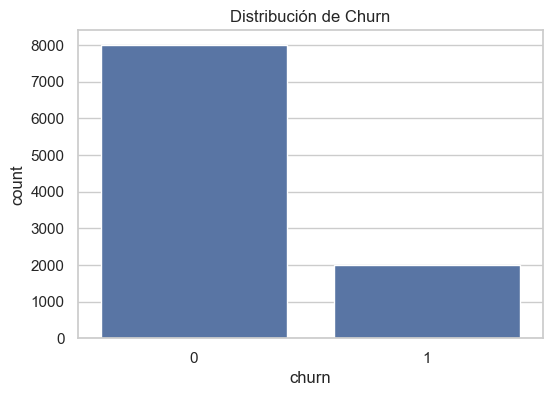

In [104]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_modelo_final, x='churn')
plt.title('Distribución de Churn')
plt.show()


In [105]:
df_modelo_final.describe()

,churn,poblacion_zona,edad,num_lineas,ingreso_estimado,antiguedad_meses,descuento_activo,num_interacciones_total,duracion_media,pct_resuelto,satisfaccion_media,interacciones_por_mes
count,"10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00"
mean,0.20,"60,004.60",39.33,2.31,"3,469.05",32.44,0.26,30.39,6.00,0.58,3.38,1.43
std,0.40,"28,724.37",11.79,1.02,"1,391.25",22.19,0.44,12.51,0.90,0.11,0.31,2.09
min,0.00,"11,707.00",18.00,1.00,900.00,-110.00,0.00,0.00,0.00,0.00,0.00,-16.50
25%,0.00,"41,163.00",31.00,2.00,"2,488.00",18.00,0.00,22.00,5.52,0.51,3.24,0.56
50%,0.00,"56,342.00",39.00,2.00,"3,219.00",29.00,0.00,30.00,6.03,0.58,3.39,0.96
75%,0.00,"72,683.00",47.00,3.00,"4,157.25",44.00,1.00,38.00,6.51,0.65,3.55,1.66
max,1.00,"107,159.00",80.00,5.00,"12,000.00",120.00,1.00,82.00,14.10,1.00,5.00,58.00


In [106]:
# Vamos a ver si hay clientes con antigüedad negativa, lo cual no tendría sentido y podría indicar un error en los datos
df_modelo_final[
    df_modelo_final['antiguedad_meses'] < 0
]

,cliente_id,churn,zona_id,region,tipo_zona,poblacion_zona,edad,sexo,estado_civil,num_lineas,tipo_plan,tipo_dispositivo,ingreso_estimado,antiguedad_meses,descuento_activo,num_interacciones_total,duracion_media,pct_resuelto,satisfaccion_media,interacciones_por_mes
31,C000032,0,Z29,Oeste,urbana_premium,67334,36.00,M,Casado/a,5,Premium,Gama baja,"2,525.00",-87.00,0,32.00,6.15,0.53,3.50,-0.37
142,C000143,0,Z29,Oeste,urbana_premium,67334,28.00,F,Soltero/a,2,Premium,Gama baja,"4,227.00",-48.00,0,19.00,6.09,0.68,3.74,-0.40
156,C000157,0,Z09,Norte,urbana_premium,102625,45.00,F,Soltero/a,3,Premium,Gama alta,"6,397.00",-37.00,1,20.00,6.83,0.55,3.45,-0.54
234,C000235,0,Z29,Oeste,urbana_premium,67334,33.00,F,Soltero/a,2,Prepago,Gama media,"2,426.00",-43.00,0,25.00,4.71,0.56,3.28,-0.58
578,C000579,0,Z27,Norte,suburbana,42704,34.00,M,Soltero/a,2,Prepago,Gama baja,"1,781.00",-18.00,0,48.00,6.20,0.60,3.52,-2.67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9839,C009840,0,Z29,Oeste,urbana_premium,67334,43.00,F,Casado/a,4,Prepago,Gama alta,"4,631.00",-28.00,0,29.00,7.43,0.62,3.69,-1.04
9901,C009902,0,Z07,Centro,rural,15473,48.00,F,Casado/a,2,Contrato,Gama media,"2,215.00",-17.00,0,34.00,7.04,0.44,3.26,-2.00
9905,C009906,0,Z22,Este,suburbana,53534,56.00,M,Casado/a,2,Premium,Gama alta,"4,210.00",-27.00,0,45.00,5.80,0.51,3.16,-1.67
9909,C009910,0,Z27,Norte,suburbana,42704,61.00,F,Soltero/a,1,Premium,Gama alta,"3,705.00",-44.00,0,34.00,6.88,0.59,3.68,-0.77


In [107]:
# Eliminamos los clientes con antigüedad negativa, ya que no tiene sentido que un cliente tenga antigüedad negativa y podría indicar un error en los datos
df_modelo_final = df_modelo_final[
    df_modelo_final['antiguedad_meses'] >= 0
]

df_modelo_final['interacciones_por_mes'] = (
    df_modelo_final['num_interacciones_total']
    / df_modelo_final['antiguedad_meses']
)

df_modelo_final['interacciones_por_mes'] = (
    df_modelo_final['interacciones_por_mes']
    .replace([np.inf, -np.inf], 0)
    .fillna(0)
)

In [108]:
df_modelo_final.describe()

,churn,poblacion_zona,edad,num_lineas,ingreso_estimado,antiguedad_meses,descuento_activo,num_interacciones_total,duracion_media,pct_resuelto,satisfaccion_media,interacciones_por_mes
count,"9,855.00","9,855.00","9,855.00","9,855.00","9,855.00","9,855.00","9,855.00","9,855.00","9,855.00","9,855.00","9,855.00","9,855.00"
mean,0.20,"60,035.10",39.32,2.30,"3,468.85",33.42,0.26,30.36,6.00,0.58,3.38,1.48
std,0.40,"28,691.34",11.81,1.02,"1,392.56",20.67,0.44,12.50,0.90,0.11,0.31,2.06
min,0.00,"11,707.00",18.00,1.00,900.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,"41,163.00",31.00,2.00,"2,487.00",18.00,0.00,22.00,5.52,0.51,3.24,0.58
50%,0.00,"56,342.00",39.00,2.00,"3,219.00",29.00,0.00,30.00,6.03,0.58,3.39,0.97
75%,0.00,"72,683.00",47.00,3.00,"4,158.50",44.00,1.00,38.00,6.51,0.65,3.55,1.67
max,1.00,"107,159.00",80.00,5.00,"12,000.00",120.00,1.00,82.00,14.10,1.00,5.00,58.00


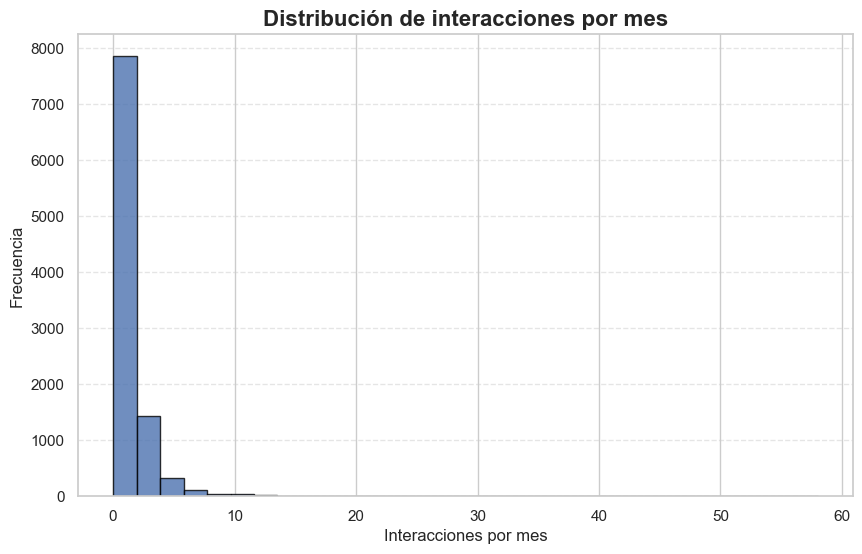

In [109]:
plt.figure(figsize=(10,6))

plt.hist(
    df_modelo_final['interacciones_por_mes'],
    bins=30,
    edgecolor='black',
    alpha=0.8)

plt.title(
    'Distribución de interacciones por mes',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel(
    'Interacciones por mes',
    fontsize=12
)

plt.ylabel(
    'Frecuencia',
    fontsize=12
)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

plt.show()

In [110]:
df_modelo_final['tipo_plan'].value_counts()

tipo_plan
Premium     4984
Prepago     2638
Contrato    2233
Name: count, dtype: int64

In [111]:
df_modelo_final['tipo_zona'].value_counts()

tipo_zona
urbana_premium    4420
suburbana         3977
rural             1458
Name: count, dtype: int64

In [112]:
df_modelo_final['region'].value_counts()

region
Oeste     2970
Este      2377
Sur       1825
Norte     1499
Centro    1184
Name: count, dtype: int64

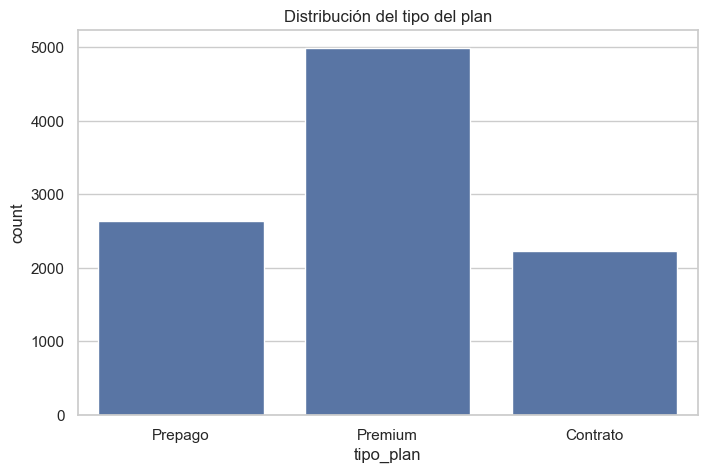

In [113]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_modelo_final, x='tipo_plan')

plt.title('Distribución del tipo del plan')
#plt.xticks(rotation=45) # Esto rota el texto de abajo por si las palabras son muy largas
plt.show()


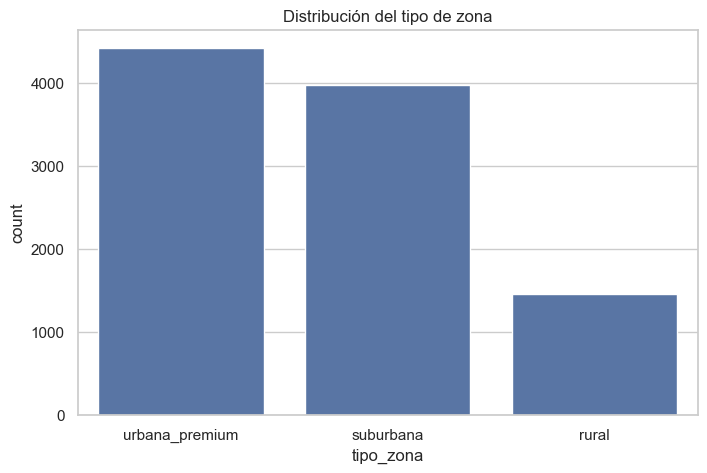

In [114]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_modelo_final, x='tipo_zona')

plt.title('Distribución del tipo de zona')
#plt.xticks(rotation=45) # Esto rota el texto de abajo por si las palabras son muy largas
plt.show()


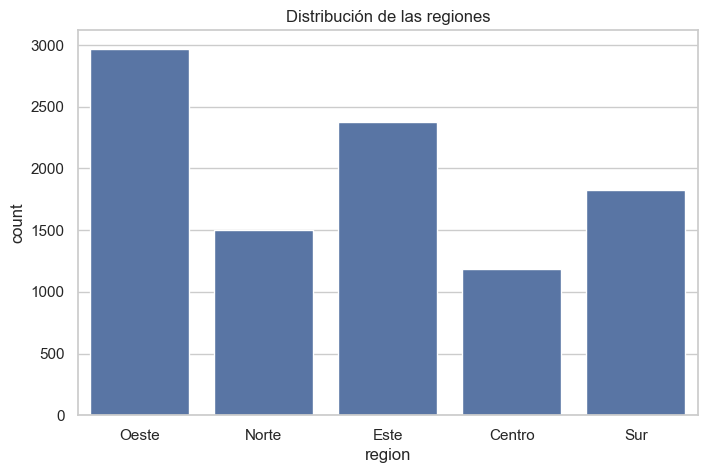

In [115]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_modelo_final, x='region')

plt.title('Distribución de las regiones')
#plt.xticks(rotation=45) # Esto rota el texto de abajo por si las palabras son muy largas
plt.show()

## ANÁLISIS BIVARIADO

In [116]:
df_modelo_final.groupby(
    'tipo_plan'
)['churn'].mean().sort_values(
    ascending=False
)

tipo_plan
Prepago    0.26
Contrato   0.21
Premium    0.16
Name: churn, dtype: float64

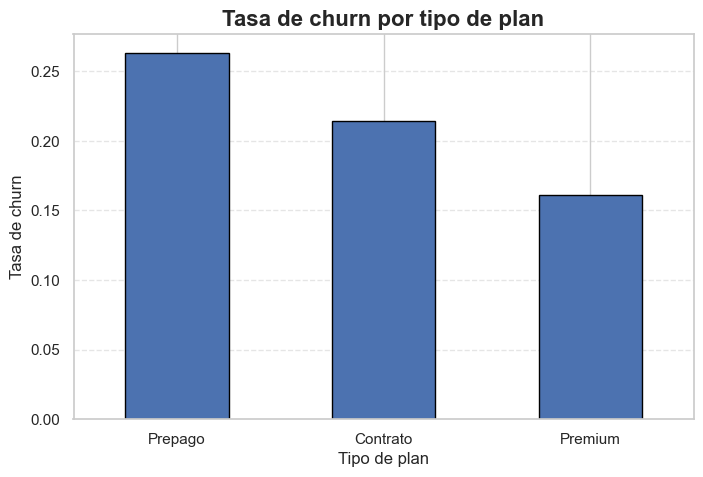

Estadístico Kruskal-Wallis: 116.667
P-valor: 0.000000


In [117]:
churn_plan = (
    df_modelo_final.groupby('tipo_plan')['churn']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

churn_plan.plot(
    kind='bar',
    edgecolor='black'
)

plt.title(
    'Tasa de churn por tipo de plan',
    fontsize=16,
    fontweight='bold'
)

plt.ylabel('Tasa de churn')
plt.xlabel('Tipo de plan')

plt.xticks(rotation=0)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

plt.show()

kw_h1 = stats.kruskal(
    *[
        group['churn'].values
        for name, group in df_modelo_final.groupby('tipo_plan')
    ]
)

print(f'Estadístico Kruskal-Wallis: {kw_h1.statistic:.3f}')
print(f'P-valor: {kw_h1.pvalue:.6f}')


El análisis bivariado muestra diferencias significativas en la tasa de churn según el tipo de plan contratado. Los clientes con planes prepago presentan la mayor tasa de abandono, mientras que los clientes premium muestran los niveles más bajos de churn. El test de Kruskal-Wallis confirma que estas diferencias son estadísticamente significativas (p < 0.001).

In [118]:
df_modelo_final.groupby(
    'tipo_zona'
)['churn'].mean().sort_values(
    ascending=False
)

tipo_zona
rural            0.33
suburbana        0.21
urbana_premium   0.14
Name: churn, dtype: float64

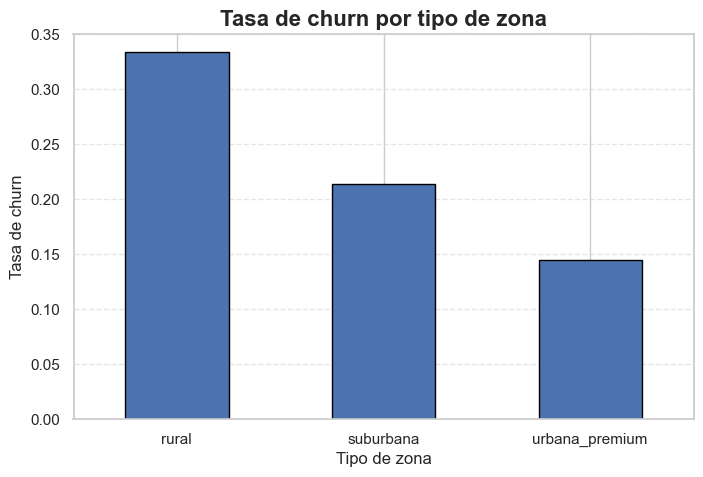

Estadístico Kruskal-Wallis: 251.216
P-valor: 0.000000


In [119]:
churn_zona = (
    df_modelo_final.groupby('tipo_zona')['churn']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

churn_zona.plot(
    kind='bar',
    edgecolor='black'
)

plt.title(
    'Tasa de churn por tipo de zona',
    fontsize=16,
    fontweight='bold'
)

plt.ylabel('Tasa de churn')
plt.xlabel('Tipo de zona')

plt.xticks(rotation=0)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

plt.show()

kw_h2 = stats.kruskal(
    *[
        group['churn'].values
        for name, group in df_modelo_final.groupby('tipo_zona')
    ]
)

print(f'Estadístico Kruskal-Wallis: {kw_h2.statistic:.3f}')
print(f'P-valor: {kw_h2.pvalue:.6f}')

El análisis bivariado evidencia diferencias significativas en la tasa de churn según el tipo de zona geográfica. Los clientes ubicados en zonas rurales presentan las mayores tasas de abandono, mientras que las zonas urbanas premium muestran los niveles más bajos de churn. Estos resultados podrían estar relacionados con diferencias en calidad de red, cobertura y experiencia de servicio entre regiones geográficas.

In [120]:
df_modelo_final.groupby(
    'region'
)['churn'].mean().sort_values(
    ascending=False
)

region
Centro   0.26
Norte    0.20
Sur      0.20
Oeste    0.19
Este     0.19
Name: churn, dtype: float64

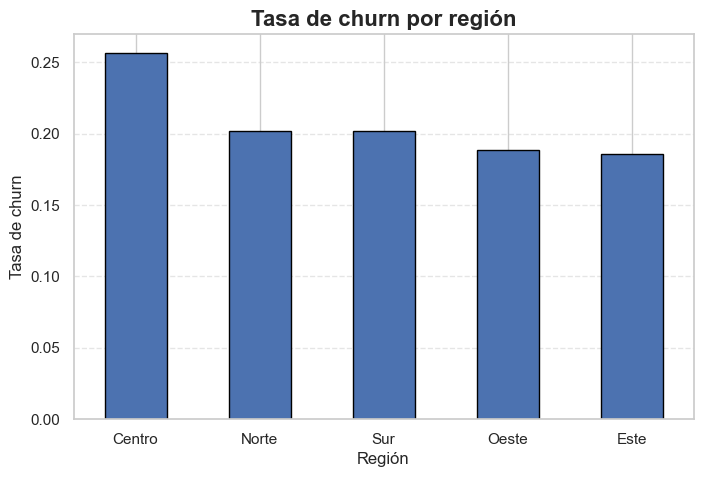

Estadístico Kruskal-Wallis: 29.381
P-valor: 0.000007


In [121]:
churn_region = (
    df_modelo_final.groupby('region')['churn']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

churn_region.plot(
    kind='bar',
    edgecolor='black'
)

plt.title(
    'Tasa de churn por región',
    fontsize=16,
    fontweight='bold'
)

plt.ylabel('Tasa de churn')
plt.xlabel('Región')

plt.xticks(rotation=0)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

plt.show()

kw_h3 = stats.kruskal(
    *[
        group['churn'].values
        for name, group in df_modelo_final.groupby('region')
    ]
)

print(f'Estadístico Kruskal-Wallis: {kw_h3.statistic:.3f}')
print(f'P-valor: {kw_h3.pvalue:.6f}')

Aunque se observan diferencias estadísticamente significativas en la tasa de churn entre regiones, el efecto visual parece más moderado en comparación con otras variables como el tipo de zona o el tipo de plan. La región Centro presenta la mayor tasa de abandono, mientras que el resto de regiones mantienen valores relativamente similares.

<Figure size 800x500 with 0 Axes>

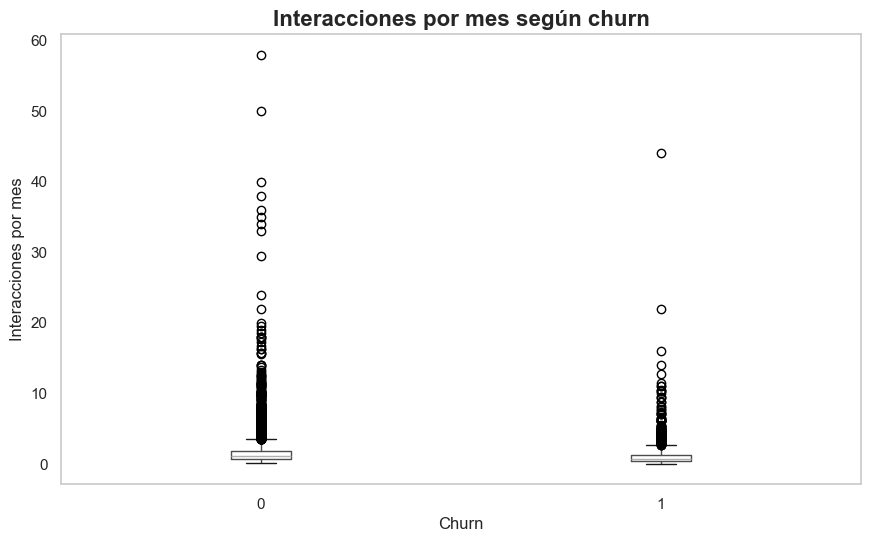

,count,mean,median,std
churn,,,,
0,7879,1.56,1.04,2.11
1,1976,1.12,0.67,1.78


Estadístico Mann-Whitney U: 10203224.500
P-valor: 0.000000


In [122]:
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# =========================
# Boxplot
# =========================

plt.figure(figsize=(8,5))

df_modelo_final.boxplot(
    column='interacciones_por_mes',
    by='churn',
    grid=False
)

plt.title(
    'Interacciones por mes según churn',
    fontsize=16,
    fontweight='bold'
)

plt.suptitle('')

plt.xlabel('Churn')
plt.ylabel('Interacciones por mes')

plt.show()

# =========================
# Estadísticos descriptivos
# =========================

summary_h4 = df_modelo_final.groupby(
    'churn'
)['interacciones_por_mes'].agg([
    'count',
    'mean',
    'median',
    'std'
])

display(summary_h4)

# =========================
# Test Mann-Whitney U
# =========================

grupo_0 = df_modelo_final[
    df_modelo_final['churn'] == 0
]['interacciones_por_mes']

grupo_1 = df_modelo_final[
    df_modelo_final['churn'] == 1
]['interacciones_por_mes']

mw_h4 = mannwhitneyu(
    grupo_0,
    grupo_1,
    alternative='two-sided'
)

print(f'Estadístico Mann-Whitney U: {mw_h4.statistic:.3f}')
print(f'P-valor: {mw_h4.pvalue:.6f}')

Contrariamente a la hipótesis inicial, los clientes que realizaron churn presentan, en promedio, un menor número de interacciones mensuales con soporte. Esto podría explicarse porque algunos clientes abandonan el servicio sin realizar contactos frecuentes con atención al cliente, o porque los clientes con mayor permanencia acumulan históricamente una mayor intensidad de uso del soporte

| Hipótesis | Resultado  | Evidencia                           |
| --------- | ---------- | ----------------------------------- |
| H1        | No apoyada | churners tienen menos interacciones |
| H2        | Apoyada    | diferencias claras por tipo_zona    |
| H3        | Apoyada    | rural presenta mayor churn          |
| H4        | Apoyada    | prepago tiene mayor churn           |


## MODELADO

### SELECCIÓN VARIABLES

In [123]:

numericas = [
    'edad',
    'num_lineas',
    'ingreso_estimado',
    'antiguedad_meses',
    'num_interacciones_total',
    'duracion_media',
    'pct_resuelto',
    'satisfaccion_media',
    'interacciones_por_mes'
]

In [124]:
categoricas = [
    'tipo_plan',
    'tipo_zona',
    'region',
    'sexo',
    'estado_civil',
    'tipo_dispositivo'
]

In [125]:
target = 'churn'

In [126]:
# Preparación de los datos para el modelo
X = df_modelo_final[
    numericas + categoricas
]

y = df_modelo_final[target]

### Train test split

In [127]:
#   Usamos stratify = y porque el churn está desbalanceado  y así mantenemos la mismma proporción de churn en train y en test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [128]:
# Creamos un preprocesador para las variables numéricas y categóricas
preprocessor = ColumnTransformer([
    (
        'num',
        StandardScaler(),
        numericas
    ),
    (
        'cat',
        OneHotEncoder(
            drop='first',
            handle_unknown='ignore'
        ),
        categoricas
    )
])

In [129]:
# Creamos un pipeline que primero aplica el preprocesador y luego entrena un modelo de regresión logística
modelo = Pipeline([
    ('preprocessing', preprocessor),
    (
        'classifier',
        LogisticRegression(
            max_iter=1000,
            class_weight='balanced'
        )
    )
])

In [130]:
modelo.fit(
    X_train,
    y_train
)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [131]:
y_pred = modelo.predict(X_test)

In [132]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.94      0.88      0.91      1576
           1       0.61      0.77      0.69       395

    accuracy                           0.86      1971
   macro avg       0.78      0.83      0.80      1971
weighted avg       0.87      0.86      0.86      1971



El modelo benchmark basado en regresión logística mostró una capacidad razonable para detectar clientes con riesgo de churn. El recall de la clase churn alcanzó aproximadamente el 77%, indicando que el modelo consigue identificar una parte importante de los clientes que abandonan el servicio. Además, el F1-score obtenido sugiere un equilibrio aceptable entre precisión (61%)y capacidad de detección en esta primera iteración.

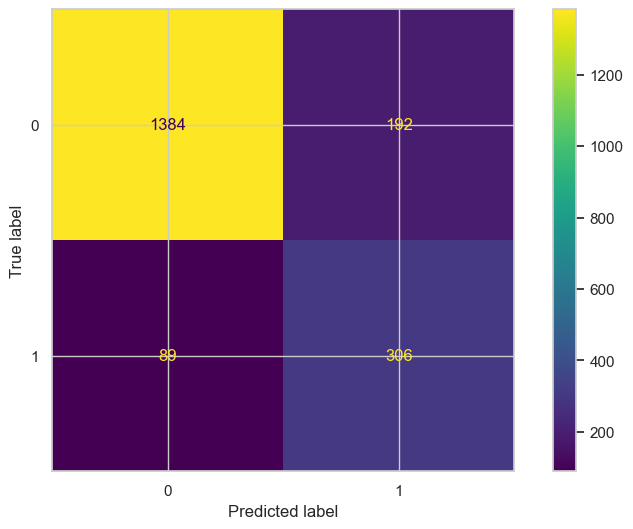

In [133]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

In [134]:
y_prob = modelo.predict_proba(X_test)[:,1]

roc_auc_score(
    y_test,
    y_prob
)

0.8994200989526442

El modelo benchmark obtuvo un ROC-AUC cercano a 0.90, indicando una buena capacidad para distinguir entre clientes con y sin riesgo de churn. Además, el recall de la clase churn fue elevado, permitiendo identificar aproximadamente el 77% de los clientes que abandonan el servicio.

,variable,coeficiente,abs_coef
12,tipo_zona_urbana_premium,-4.81,4.81
11,tipo_zona_suburbana,-2.74,2.74
4,num_interacciones_total,-2.54,2.54
10,tipo_plan_Prepago,1.13,1.13
21,estado_civil_Desconocido,-0.87,0.87
14,region_Norte,0.42,0.42
19,sexo_M,0.38,0.38
17,sexo_Desconocido,0.37,0.37
18,sexo_F,0.33,0.33
25,tipo_dispositivo_Gama baja,0.29,0.29


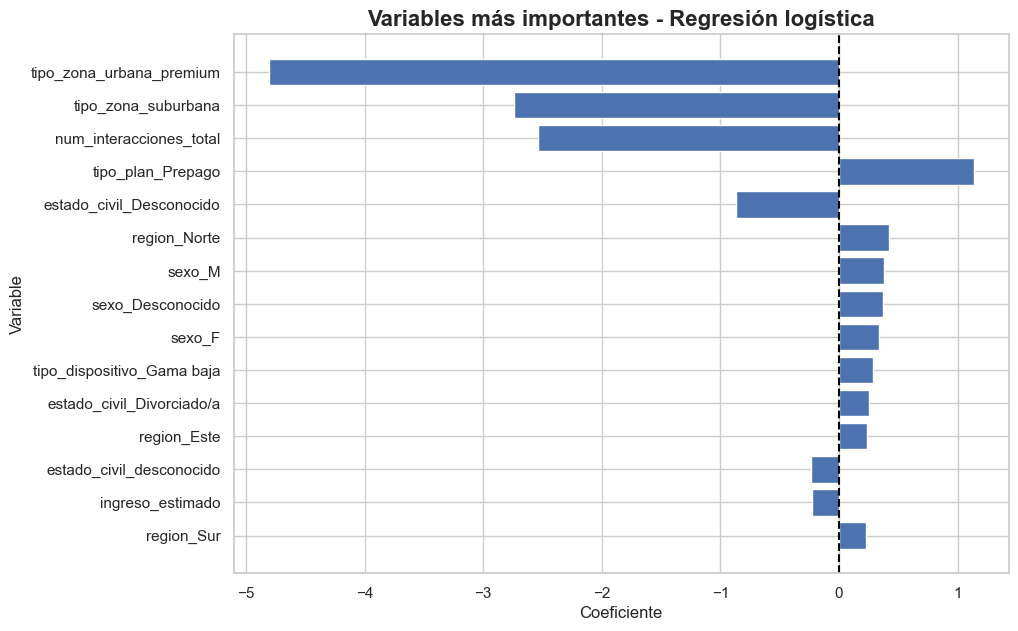

In [135]:
# Análisis de coeficientes

# Sacar nombres columnas
# =========================

feature_names = (
    numericas
    +
    list(
        modelo.named_steps[
            'preprocessing'
        ]
        .named_transformers_['cat']
        .get_feature_names_out(categoricas)
    )
)

# =========================
# Sacar coeficientes
# =========================

coeficientes = (
    modelo.named_steps['classifier']
    .coef_[0]
)

# =========================
# Crear dataframe
# =========================

coef_df = pd.DataFrame({
    'variable': feature_names,
    'coeficiente': coeficientes
})

# =========================
# Ordenar por importancia
# =========================

coef_df['abs_coef'] = np.abs(
    coef_df['coeficiente']
)

coef_df = coef_df.sort_values(
    'abs_coef',
    ascending=False
)

display(coef_df.head(15))

# =========================
# Gráfico
# =========================

top_coef = coef_df.head(15)

plt.figure(figsize=(10,7))

plt.barh(
    top_coef['variable'],
    top_coef['coeficiente']
)

plt.axvline(
    x=0,
    color='black',
    linestyle='--'
)

plt.title(
    'Variables más importantes - Regresión logística',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Coeficiente')
plt.ylabel('Variable')

plt.gca().invert_yaxis()

plt.show()

In [136]:
# Predicción de probabilidades
y_prob = modelo.predict_proba(X_test)[:,1]

In [137]:
threshold = 0.7

In [138]:
# Predicción de clases según el umbral
y_pred_new = (
    y_prob >= threshold
).astype(int)

In [139]:

print(
    classification_report(
        y_test,
        y_pred_new
    )
)

print(
    confusion_matrix(
        y_test,
        y_pred_new
    )
)

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      1576
           1       0.82      0.67      0.74       395

    accuracy                           0.90      1971
   macro avg       0.87      0.82      0.84      1971
weighted avg       0.90      0.90      0.90      1971

[[1517   59]
 [ 129  266]]


#  2º ITERACIÓN


Añadimos facturación ID para poder observar el comportamiento económico y temporal de los clientes

In [140]:
df_facturacion = pd.read_csv(
    r"C:\Users\Usuario\Documents\Andrea\prácticas\UCV-Churn\data\raw\facturacion_mensual.csv"
)

In [141]:
df_facturacion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 326816 entries, 0 to 326815
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   cliente_id             326816 non-null  object 
 1   fecha                  326816 non-null  object 
 2   zona_id                326816 non-null  object 
 3   tipo_plan              317000 non-null  object 
 4   num_lineas             326816 non-null  int64  
 5   cargo_base             326816 non-null  float64
 6   consumo_extra          326816 non-null  float64
 7   descuento_aplicado     326816 non-null  float64
 8   importe_total          317017 non-null  float64
 9   dias_retraso_pago      326816 non-null  int64  
 10  impago_flag            326816 non-null  int64  
 11  variacion_consumo_pct  326816 non-null  float64
 12  stress_calidad_lag     326816 non-null  float64
 13  incidencia_masiva_lag  326816 non-null  int64  
dtypes: float64(6), int64(4), object(4)
m

In [142]:
df_facturacion.isnull().sum()

cliente_id                  0
fecha                       0
zona_id                     0
tipo_plan                9816
num_lineas                  0
cargo_base                  0
consumo_extra               0
descuento_aplicado          0
importe_total            9799
dias_retraso_pago           0
impago_flag                 0
variacion_consumo_pct       0
stress_calidad_lag          0
incidencia_masiva_lag       0
dtype: int64

Solo eliminamos el nulo de importe total ya que el tipo de plan ya lo tenemos en el modelo_final como variable y limpio

In [143]:
# Vamos a rellenar los valores nulos de la columna 'importe_total' con la mediana de la misma columna, ya que es una variable numérica y la mediana es menos sensible a los valores atípicos que la media. Esto nos permitirá mantener la distribución de los datos sin introducir sesgos significativos.
df_facturacion['importe_total'] = (
    df_facturacion['importe_total']
    .fillna(
        df_facturacion['importe_total'].median()
    )
)

In [144]:
df_facturacion.duplicated().sum()

np.int64(4829)

In [145]:
df_facturacion[
    df_facturacion.duplicated()
].head()

,cliente_id,fecha,zona_id,tipo_plan,num_lineas,cargo_base,consumo_extra,descuento_aplicado,importe_total,dias_retraso_pago,impago_flag,variacion_consumo_pct,stress_calidad_lag,incidencia_masiva_lag
321987,C007415,2023-10-01,Z21,Prepago,2,46.63,2.55,0.00,49.18,22,1,2.55,0.78,0
321988,C006590,2023-09-01,Z16,Contrato,4,144.40,0.41,0.00,144.81,0,0,-0.95,0.40,0
321989,C006021,2023-09-01,Z30,Premium,2,124.20,0.00,0.00,124.20,0,0,-1.00,0.53,0
321990,C008268,2023-02-01,Z06,Premium,1,77.29,4.29,0.00,81.59,0,0,-0.43,0.71,0
321991,C007927,2023-03-01,Z06,Prepago,1,22.71,7.99,0.00,30.70,0,0,0.96,0.68,0


In [146]:
df_facturacion[
    df_facturacion.duplicated(
        subset=['cliente_id', 'fecha']
    )
].head()

,cliente_id,fecha,zona_id,tipo_plan,num_lineas,cargo_base,consumo_extra,descuento_aplicado,importe_total,dias_retraso_pago,impago_flag,variacion_consumo_pct,stress_calidad_lag,incidencia_masiva_lag
321987,C007415,2023-10-01,Z21,Prepago,2,46.63,2.55,0.00,49.18,22,1,2.55,0.78,0
321988,C006590,2023-09-01,Z16,Contrato,4,144.40,0.41,0.00,144.81,0,0,-0.95,0.40,0
321989,C006021,2023-09-01,Z30,Premium,2,124.20,0.00,0.00,124.20,0,0,-1.00,0.53,0
321990,C008268,2023-02-01,Z06,Premium,1,77.29,4.29,0.00,81.59,0,0,-0.43,0.71,0
321991,C007927,2023-03-01,Z06,Prepago,1,22.71,7.99,0.00,30.70,0,0,0.96,0.68,0


In [147]:
df_facturacion = df_facturacion.drop_duplicates()

In [148]:
df_facturacion.duplicated().sum()

np.int64(0)

Se identificaron registros duplicados completos en la tabla de facturación mensual. Al tratarse de duplicados exactos en todas las variables, se procedió a su eliminación para evitar sesgos en el análisis y en la construcción de variables agregadas.

In [149]:
# Agregación de datos de facturación
facturacion_agg = df_facturacion.groupby(
    'cliente_id'
).agg({

    'importe_total': 'mean',
    'dias_retraso_pago': 'mean',
    'impago_flag': ['sum', 'mean'],
    'variacion_consumo_pct': 'mean',
    'stress_calidad_lag': 'mean',
    'incidencia_masiva_lag': 'sum'

}).reset_index()

In [150]:
# Renombramos las columnas para que sean más descriptivas
facturacion_agg.columns = [
    'cliente_id',
    'importe_medio',
    'retraso_pago_medio',
    'num_impagos',
    'pct_impagos',
    'variacion_consumo_media',
    'stress_red_medio',
    'num_incidencias_masivas'
]

In [151]:
# Unimos el dataframe de facturación agregada con el dataframe final para tener toda la información en un solo dataframe
df_modelo_v2 = df_modelo_final.merge(
    facturacion_agg,
    on='cliente_id',
    how='left'
)

In [152]:
df_modelo_v2.isnull().sum()

cliente_id                 0
churn                      0
zona_id                    0
region                     0
tipo_zona                  0
poblacion_zona             0
edad                       0
sexo                       0
estado_civil               0
num_lineas                 0
tipo_plan                  0
tipo_dispositivo           0
ingreso_estimado           0
antiguedad_meses           0
descuento_activo           0
num_interacciones_total    0
duracion_media             0
pct_resuelto               0
satisfaccion_media         0
interacciones_por_mes      0
importe_medio              0
retraso_pago_medio         0
num_impagos                0
pct_impagos                0
variacion_consumo_media    0
stress_red_medio           0
num_incidencias_masivas    0
dtype: int64

In [153]:

numericas_v2 = [
    'edad',
    'num_lineas',
    'ingreso_estimado',
    'antiguedad_meses',
    'num_interacciones_total',
    'duracion_media',
    'pct_resuelto',
    'satisfaccion_media',
    'interacciones_por_mes',

    # NUEVAS
    'importe_medio',
    'retraso_pago_medio',
    'num_impagos',
    'pct_impagos',
    'variacion_consumo_media',
    'stress_red_medio',
    'num_incidencias_masivas'
]

In [154]:
categoricas_v2 = [
    'tipo_plan',
    'tipo_zona',
    'region',
    'sexo',
    'estado_civil',
    'tipo_dispositivo'
]

In [155]:
X = df_modelo_v2[
    numericas_v2 + categoricas_v2
]

y = df_modelo_v2['churn']

In [156]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [157]:

preprocessor = ColumnTransformer([
    (
        'num',
        StandardScaler(),
        numericas_v2
    ),
    (
        'cat',
        OneHotEncoder(
            drop='first',
            handle_unknown='ignore'
        ),
        categoricas_v2
    )
])

In [158]:

modelo_v2 = Pipeline([
    ('preprocessing', preprocessor),
    (
        'classifier',
        LogisticRegression(
            max_iter=1000,
            class_weight='balanced'
        )
    )
])

In [159]:
modelo_v2.fit(
    X_train,
    y_train
)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [160]:
y_pred = modelo_v2.predict(X_test)

In [161]:

print(
    classification_report(
        y_test,
        y_pred
    )
)

y_prob = modelo_v2.predict_proba(X_test)[:,1]

print(
    'ROC-AUC:',
    roc_auc_score(
        y_test,
        y_prob
    )
)

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1576
           1       0.96      0.91      0.94       395

    accuracy                           0.97      1971
   macro avg       0.97      0.95      0.96      1971
weighted avg       0.97      0.97      0.97      1971

ROC-AUC: 0.98161665488659


,variable,coeficiente,abs_coef
12,pct_impagos,16.53,16.53
11,num_impagos,-11.16,11.16
21,region_Norte,2.29,2.29
4,num_interacciones_total,-2.03,2.03
14,stress_red_medio,1.98,1.98
19,tipo_zona_urbana_premium,1.29,1.29
17,tipo_plan_Prepago,1.08,1.08
18,tipo_zona_suburbana,0.75,0.75
15,num_incidencias_masivas,-0.71,0.71
26,sexo_M,0.52,0.52


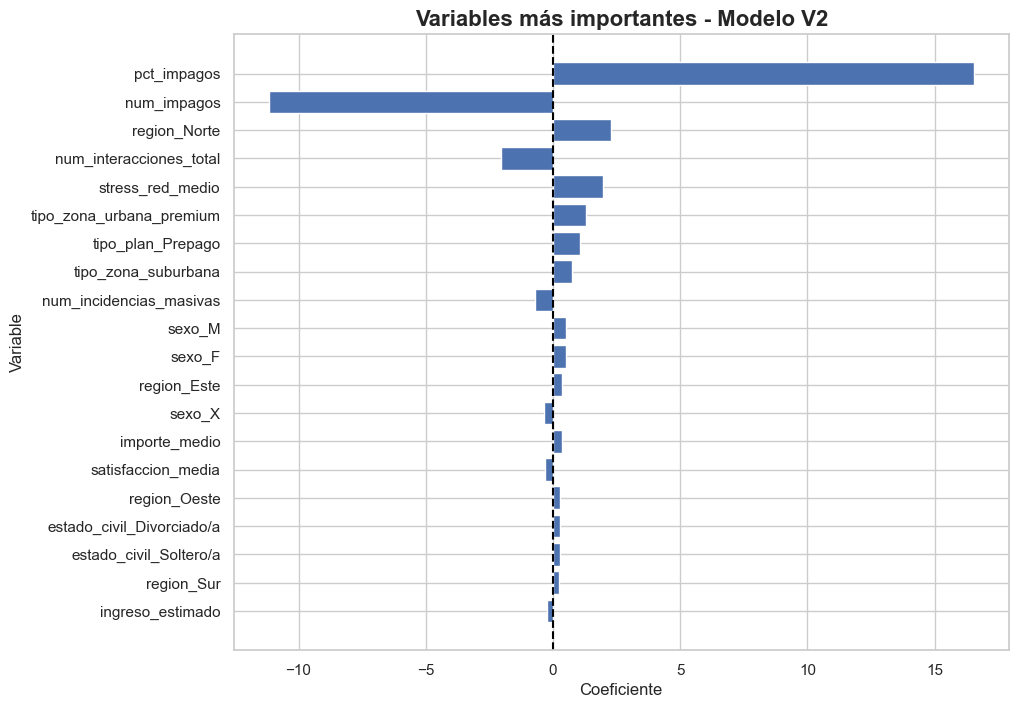

In [162]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Nombres columnas
# =========================

feature_names = (
    numericas_v2
    +
    list(
        modelo_v2.named_steps[
            'preprocessing'
        ]
        .named_transformers_['cat']
        .get_feature_names_out(categoricas_v2)
    )
)

# =========================
# Coeficientes
# =========================

coeficientes = (
    modelo_v2.named_steps[
        'classifier'
    ].coef_[0]
)

# =========================
# Dataframe
# =========================

coef_df = pd.DataFrame({
    'variable': feature_names,
    'coeficiente': coeficientes
})

coef_df['abs_coef'] = np.abs(
    coef_df['coeficiente']
)

coef_df = coef_df.sort_values(
    'abs_coef',
    ascending=False
)

display(coef_df.head(20))

# =========================
# Gráfico
# =========================

top_coef = coef_df.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top_coef['variable'],
    top_coef['coeficiente']
)

plt.axvline(
    x=0,
    color='black',
    linestyle='--'
)

plt.title(
    'Variables más importantes - Modelo V2',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Coeficiente')
plt.ylabel('Variable')

plt.gca().invert_yaxis()

plt.show()

vamos a quitar pct_impagos ya que domina todo el modelo y además puede que esté ocasionado data leakage

In [163]:
numericas_v3 = [
    'edad',
    'num_lineas',
    'ingreso_estimado',
    'antiguedad_meses',
    'num_interacciones_total',
    'duracion_media',
    'pct_resuelto',
    'satisfaccion_media',
    'interacciones_por_mes',

    # NUEVAS
    'importe_medio',
    'retraso_pago_medio',
    'num_impagos',
    'variacion_consumo_media',
    'stress_red_medio',
    'num_incidencias_masivas'
]

In [164]:
categoricas_v3 = [
    'tipo_plan',
    'tipo_zona',
    'region',
    'sexo',
    'estado_civil',
    'tipo_dispositivo'
]

In [165]:
X = df_modelo_v2[
    numericas_v3 + categoricas_v3
]

y = df_modelo_v2['churn']

In [166]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [167]:

preprocessor = ColumnTransformer([
    (
        'num',
        StandardScaler(),
        numericas_v3
    ),
    (
        'cat',
        OneHotEncoder(
            drop='first',
            handle_unknown='ignore'
        ),
        categoricas_v3
    )
])

In [168]:

modelo_v3 = Pipeline([
    ('preprocessing', preprocessor),
    (
        'classifier',
        LogisticRegression(
            max_iter=1000,
            class_weight='balanced'
        )
    )
])

In [169]:
modelo_v3.fit(
    X_train,
    y_train
)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [170]:
y_pred = modelo_v3.predict(X_test)

In [171]:

print(
    classification_report(
        y_test,
        y_pred
    )
)

y_prob = modelo_v3.predict_proba(X_test)[:,1]

print(
    'ROC-AUC:',
    roc_auc_score(
        y_test,
        y_prob
    )
)

              precision    recall  f1-score   support

           0       0.96      0.91      0.93      1576
           1       0.70      0.84      0.77       395

    accuracy                           0.90      1971
   macro avg       0.83      0.88      0.85      1971
weighted avg       0.91      0.90      0.90      1971

ROC-AUC: 0.9381047998457881


,variable,coeficiente,abs_coef
18,tipo_zona_urbana_premium,4.81,4.81
13,stress_red_medio,3.62,3.62
20,region_Norte,3.15,3.15
4,num_interacciones_total,-2.86,2.86
17,tipo_zona_suburbana,2.77,2.77
16,tipo_plan_Prepago,1.45,1.45
14,num_incidencias_masivas,-1.06,1.06
10,retraso_pago_medio,0.62,0.62
27,estado_civil_Desconocido,-0.56,0.56
7,satisfaccion_media,-0.49,0.49


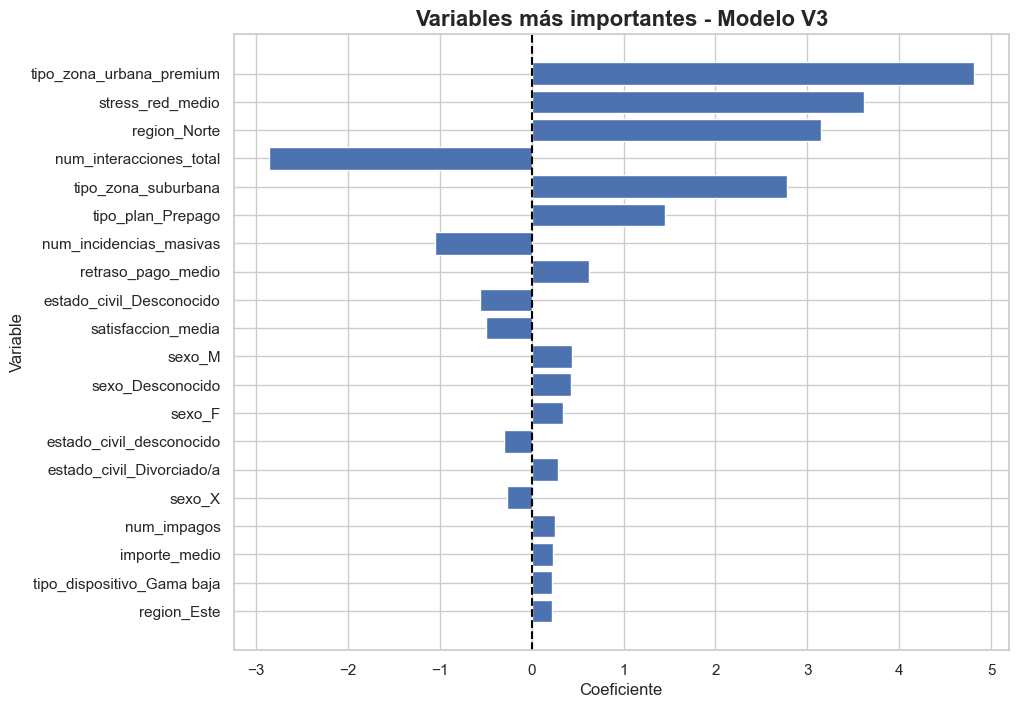

In [172]:

# =========================
# Nombres columnas
# =========================

feature_names = (
    numericas_v3
    +
    list(
        modelo_v3.named_steps[
            'preprocessing'
        ]
        .named_transformers_['cat']
        .get_feature_names_out(categoricas_v3)
    )
)

# =========================
# Coeficientes
# =========================

coeficientes = (
    modelo_v3.named_steps[
        'classifier'
    ].coef_[0]
)

# =========================
# Dataframe
# =========================

coef_df = pd.DataFrame({
    'variable': feature_names,
    'coeficiente': coeficientes
})

coef_df['abs_coef'] = np.abs(
    coef_df['coeficiente']
)

coef_df = coef_df.sort_values(
    'abs_coef',
    ascending=False
)

display(coef_df.head(20))

# =========================
# Gráfico
# =========================

top_coef = coef_df.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top_coef['variable'],
    top_coef['coeficiente']
)

plt.axvline(
    x=0,
    color='black',
    linestyle='--'
)

plt.title(
    'Variables más importantes - Modelo V3',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Coeficiente')
plt.ylabel('Variable')

plt.gca().invert_yaxis()

plt.show()

Solo eliminamos el nulo de importe total ya que el tipo de plan ya lo tenemos en el modelo_final como variable y limpio

# 3º TERACIÓN 

Vamos a pasar a usar cliente-mes y añadir el churn en los próximos tres meses

In [173]:
df_facturacion_original = pd.read_csv(
    r"C:\Users\Usuario\Documents\Andrea\prácticas\UCV-Churn\data\raw\facturacion_mensual.csv"
)

print(df_facturacion_original.shape)

(326816, 14)


In [174]:
df_facturacion = df_facturacion_original.copy()

print(df_facturacion.shape)

(326816, 14)


In [175]:
print(df_facturacion_original.shape)
print(df_facturacion.shape)

(326816, 14)
(326816, 14)


In [176]:

#Función para convertir fechas en diferentes formatos a datetime
def convertir_fecha(x):
    x = str(x)

    if '-' in x:
        return pd.to_datetime(x, format='%Y-%m-%d')

    elif '/' in x:
        return pd.to_datetime(x, format='%d/%m/%Y')

    return pd.NaT

df_facturacion['fecha'] = df_facturacion['fecha'].apply(convertir_fecha)

In [177]:
df_facturacion['fecha'].dtype

dtype('<M8[ns]')

In [178]:
df_facturacion = df_facturacion.rename(
    columns={'fecha':'mes'}
)

In [179]:
# Vamos a convertir la columna 'fecha' del dataframe df_churn a tipo datetime para poder trabajar con ella de manera más eficiente y realizar análisis temporales si es necesario. Esto nos permitirá manipular las fechas de manera más sencilla, como filtrar por rangos de fechas, extraer componentes de la fecha (año, mes, día), y realizar operaciones de tiempo.
df_churn['fecha'] = pd.to_datetime(df_churn['fecha'])

df_churn = df_churn.rename(
    columns={'fecha': 'mes'}
)

In [180]:
# Unimos el dataframe de churn con el dataframe de facturación para tener toda la información en un solo dataframe
df_modelo_temp = df_churn.merge(
    df_facturacion,
    on=['cliente_id', 'mes'],
    how='left'
)

print(df_modelo_temp.shape)

(326816, 15)


In [181]:
df_modelo_temp.isnull().sum().sort_values(ascending=False).head(20)

tipo_plan                9816
importe_total            9799
mes                         0
churn                       0
zona_id                     0
num_lineas                  0
cliente_id                  0
cargo_base                  0
consumo_extra               0
descuento_aplicado          0
dias_retraso_pago           0
impago_flag                 0
variacion_consumo_pct       0
stress_calidad_lag          0
incidencia_masiva_lag       0
dtype: int64

In [182]:
# Vamos a rellenar los valores nulos de la columna 'tipo_plan' con 'Desconocido', ya que es una variable categórica y no tiene sentido eliminar filas por tener un valor nulo en esta columna. Esto nos permitirá mantener la mayor cantidad de datos posible para el análisis y modelado.
df_facturacion['tipo_plan'] = (
    df_facturacion['tipo_plan']
    .fillna('Desconocido')
)

df_facturacion['importe_total'] = (
    df_facturacion['importe_total']
    .fillna(df_facturacion['importe_total'].median())
)

In [183]:
# Vamos a convertir el dataframe de soporte a un formato más adecuado para el análisis.
soporte_agg = (
    df_soporte
    .groupby(['cliente_id', 'mes'])
    .agg(
        num_interacciones=('interaccion_id', 'count'),
        duracion_media=('duracion_min', 'mean'),
        pct_resuelto=('resuelto', 'mean'),
        satisfaccion_media=('satisfaccion_post', 'mean')
    )
    .reset_index()
)

In [184]:
# Vamos a convertir la columna 'mes' del dataframe soporte_agg a tipo datetime 
soporte_agg['mes'] = pd.to_datetime(
    soporte_agg['mes']
)
df_modelo_temp = df_churn.merge(
    df_facturacion,
    on=['cliente_id','mes'],
    how='left'
)

df_modelo_temp = df_modelo_temp.merge(
    soporte_agg,
    on=['cliente_id','mes'],
    how='left'
)

In [185]:
df_modelo_temp.isnull().sum().sort_values(ascending=False).head(20)

pct_resuelto             145030
duracion_media           145030
num_interacciones        145030
satisfaccion_media       145030
churn                         0
cliente_id                    0
mes                           0
zona_id                       0
tipo_plan                     0
num_lineas                    0
cargo_base                    0
dias_retraso_pago             0
importe_total                 0
descuento_aplicado            0
consumo_extra                 0
incidencia_masiva_lag         0
stress_calidad_lag            0
variacion_consumo_pct         0
impago_flag                   0
dtype: int64

In [186]:
cols_soporte = [
    'num_interacciones',
    'duracion_media',
    'pct_resuelto',
    'satisfaccion_media'
]

df_modelo_temp[cols_soporte] = (
    df_modelo_temp[cols_soporte]
    .fillna(0)
)

In [187]:
#  Creamos la variable de churn_3m 
df_modelo_temp = (
    df_modelo_temp
    .sort_values(['cliente_id', 'mes'])
)

df_modelo_temp['churn_3m'] = (
    df_modelo_temp
    .groupby('cliente_id')['churn']
    .transform(
        lambda x:
        (
            x.shift(-1).fillna(0)
            + x.shift(-2).fillna(0)
            + x.shift(-3).fillna(0)
        ) > 0
    )
    .astype(int)
)

In [188]:
df_modelo_temp['churn_3m'].value_counts()

churn_3m
0    320980
1      5836
Name: count, dtype: int64

In [189]:
columnas_excluir = [
    'cliente_id',
    'mes',
    'churn',
    'churn_3m'
]

In [190]:
X = df_modelo_temp.drop(columns=columnas_excluir)

y = df_modelo_temp['churn_3m']

In [191]:
# Vamos a dividir el dataframe df_modelo_temp en un conjunto de entrenamiento y un conjunto de prueba. Para ello, vamos a utilizar la fecha de corte '2025-07-01'. Todos los registros con una fecha anterior a esta fecha se incluirán en el conjunto de entrenamiento, mientras que todos los registros con una fecha igual o posterior a esta fecha se incluirán en el conjunto de prueba
fecha_corte = '2025-07-01'

train = df_modelo_temp[
    df_modelo_temp['mes'] < fecha_corte
]

test = df_modelo_temp[
    df_modelo_temp['mes'] >= fecha_corte
]

In [192]:

X_train = train.drop(
    columns=['cliente_id','mes','churn','churn_3m']
)

y_train = train['churn_3m']

X_test = test.drop(
    columns=['cliente_id','mes','churn','churn_3m']
)

y_test = test['churn_3m']

In [193]:
# iden
cat_cols = X_train.select_dtypes(
    include=['object']
).columns.tolist()

num_cols = X_train.select_dtypes(
    exclude=['object']
).columns.tolist()

print(cat_cols)
print(num_cols)

['zona_id', 'tipo_plan']
['num_lineas', 'cargo_base', 'consumo_extra', 'descuento_aplicado', 'importe_total', 'dias_retraso_pago', 'impago_flag', 'variacion_consumo_pct', 'stress_calidad_lag', 'incidencia_masiva_lag', 'num_interacciones', 'duracion_media', 'pct_resuelto', 'satisfaccion_media']


In [194]:
preprocessing = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [195]:
# Creamos un pipeline que primero aplica el preprocesador y luego entrena un modelo de regresión logística
pipeline = Pipeline([
    ('preprocessing', preprocessing),
    (
        'modelo',
        LogisticRegression(
            max_iter=5000,
            class_weight='balanced',
            random_state=42
        )
    )
])

In [196]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('modelo', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [197]:
y_pred = pipeline.predict(X_test)

y_prob = pipeline.predict_proba(X_test)[:,1]

In [198]:


print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob)
)

              precision    recall  f1-score   support

           0       0.99      0.73      0.84     49111
           1       0.02      0.50      0.04       496

    accuracy                           0.73     49607
   macro avg       0.51      0.61      0.44     49607
weighted avg       0.98      0.73      0.83     49607

[[35866 13245]
 [  249   247]]
ROC-AUC: 0.6637343417577429


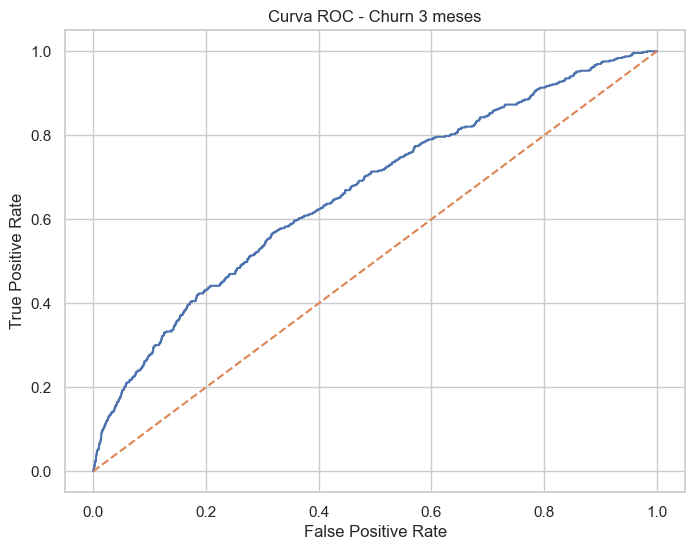

In [199]:
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Churn 3 meses")
plt.grid(True)
plt.show()

In [200]:
# ==========================================================
# NOMBRES DE VARIABLES
# ==========================================================

feature_names = (
    num_cols
    +
    list(
        pipeline.named_steps['preprocessing']
        .named_transformers_['cat']
        .get_feature_names_out(cat_cols)
    )
)

# ==========================================================
# COEFICIENTES
# ==========================================================

coeficientes = (
    pipeline.named_steps['modelo']
    .coef_[0]
)

importancia = pd.DataFrame({
    'variable': feature_names,
    'coeficiente': coeficientes
})

importancia['abs_coef'] = (
    importancia['coeficiente']
    .abs()
)

importancia = (
    importancia
    .sort_values(
        'abs_coef',
        ascending=False
    )
)

importancia.head(20)

,variable,coeficiente,abs_coef
20,zona_id_Z07,0.44,0.44
31,zona_id_Z18,-0.42,0.42
39,zona_id_Z26,-0.41,0.41
14,zona_id_Z01,0.39,0.39
42,zona_id_Z29,-0.38,0.38
18,zona_id_Z05,-0.35,0.35
19,zona_id_Z06,0.31,0.31
32,zona_id_Z19,0.31,0.31
22,zona_id_Z09,-0.29,0.29
16,zona_id_Z03,0.29,0.29


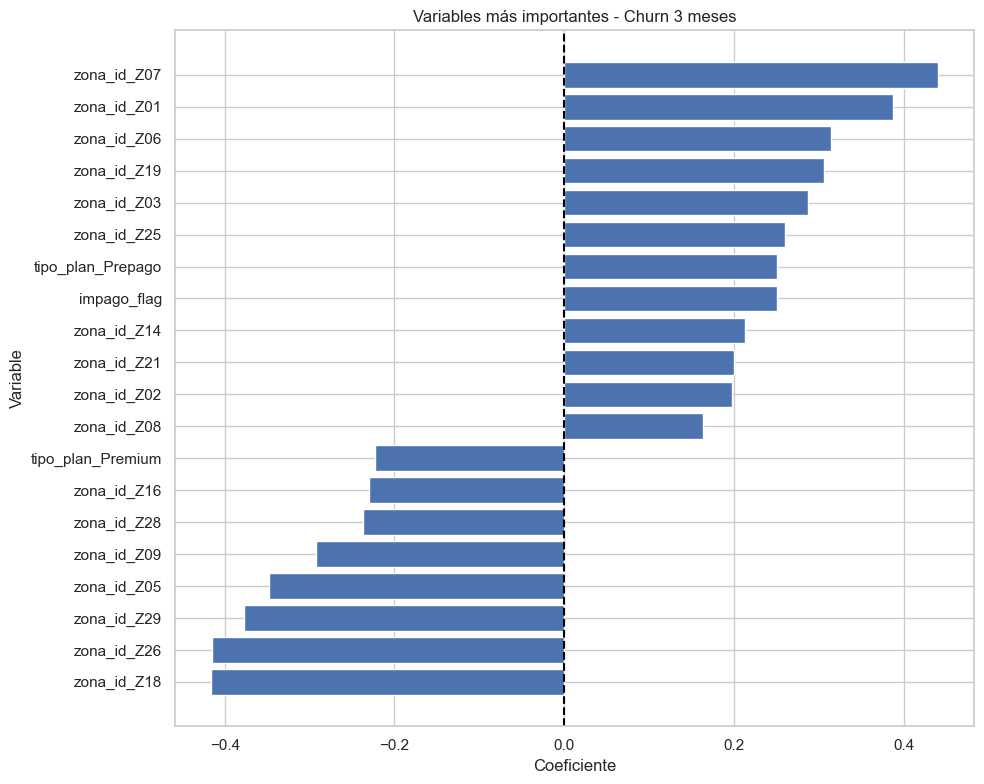

In [201]:

top_n = 20

top_vars = (
    importancia
    .head(top_n)
    .sort_values('coeficiente')
)

plt.figure(figsize=(10,8))

plt.barh(
    top_vars['variable'],
    top_vars['coeficiente']
)

plt.axvline(
    x=0,
    color='black',
    linestyle='--'
)

plt.title(
    'Variables más importantes - Churn 3 meses'
)

plt.xlabel('Coeficiente')
plt.ylabel('Variable')

plt.tight_layout()
plt.show()

In [202]:
print(X.columns.tolist())

['zona_id', 'tipo_plan', 'num_lineas', 'cargo_base', 'consumo_extra', 'descuento_aplicado', 'importe_total', 'dias_retraso_pago', 'impago_flag', 'variacion_consumo_pct', 'stress_calidad_lag', 'incidencia_masiva_lag', 'num_interacciones', 'duracion_media', 'pct_resuelto', 'satisfaccion_media']


# 4º ITERACIÓN

En esta iteración se añadirán variables acumuladas de los últimos 3 meses al modelo que tenemos-


In [203]:
df_modelo_temp1 = df_modelo_temp.sort_values(
    ['cliente_id','mes']
)

In [204]:
# Calculamos el importe promedio de los últimos 3 meses para cada cliente
df_modelo_temp1['importe_3m'] = (
    df_modelo_temp1
    .groupby('cliente_id')['importe_total']
    .transform(
        lambda x: x.shift(1).rolling(3,min_periods=1).mean()
    )
)

In [205]:
# Calculamos el retraso promedio de los últimos 3 meses para cada cliente
df_modelo_temp1['retraso_3m'] = (
    df_modelo_temp1
    .groupby('cliente_id')['dias_retraso_pago']
    .transform(
        lambda x: x.shift(1).rolling(3,min_periods=1).mean()
    )
)

In [206]:
# Calculamos el número de impagos de los últimos 3 meses para cada cliente
df_modelo_temp1['impagos_3m'] = (
    df_modelo_temp1
    .groupby('cliente_id')['impago_flag']
    .transform(
        lambda x: x.shift(1).rolling(3,min_periods=1).sum()
    )
)

In [207]:
# Calculamos la variación promedio del consumo de los últimos 3 meses para cada cliente
df_modelo_temp1['interacciones_3m'] = (
    df_modelo_temp1
    .groupby('cliente_id')['num_interacciones']
    .transform(
        lambda x: x.shift(1).rolling(3,min_periods=1).sum()
    )
)

In [208]:
# Calculamos la satisfacción promedio de los últimos 3 meses para cada cliente 
df_modelo_temp1['satisfaccion_3m'] = (
    df_modelo_temp1
    .groupby('cliente_id')['satisfaccion_media']
    .transform(
        lambda x: x.shift(1).rolling(3,min_periods=1).mean()
    )
)

In [209]:
# Creamos un nuevo dataframe con las variables que vamos a utilizar para el modelo de churn a 3 meses
features = [
'zona_id',
'tipo_plan',
'num_lineas',
'cargo_base',
'consumo_extra',
'descuento_aplicado',
'importe_total',
'dias_retraso_pago',
'impago_flag',
'variacion_consumo_pct',
'stress_calidad_lag',
'incidencia_masiva_lag',
'num_interacciones',
'duracion_media',
'pct_resuelto',
'satisfaccion_media',

'importe_3m',
'retraso_3m',
'impagos_3m',
'interacciones_3m',
'satisfaccion_3m'
]

In [210]:
df_modelo_temp1.isna().sum().sort_values(ascending=False).head(20)

retraso_3m               10000
satisfaccion_3m          10000
interacciones_3m         10000
impagos_3m               10000
importe_3m               10000
mes                          0
churn                        0
zona_id                      0
cliente_id                   0
descuento_aplicado           0
consumo_extra                0
cargo_base                   0
num_lineas                   0
tipo_plan                    0
importe_total                0
impago_flag                  0
dias_retraso_pago            0
duracion_media               0
num_interacciones            0
incidencia_masiva_lag        0
dtype: int64

In [211]:
# cambiamos los valores nulos de las variables de los últimos 3 meses por 0, ya que si un cliente no tiene datos de los últimos 3 meses es porque no ha tenido actividad en ese periodo y por lo tanto no ha tenido impagos, retrasos, interacciones ni satisfacción. Por lo tanto, tiene sentido rellenar esos valores nulos con 0.
df_modelo_temp1[['importe_3m',
                'retraso_3m',
                'impagos_3m',
                'interacciones_3m',
                'satisfaccion_3m']] = (
    df_modelo_temp1[['importe_3m',
                    'retraso_3m',
                    'impagos_3m',
                    'interacciones_3m',
                    'satisfaccion_3m']]
    .fillna(0)
)

In [212]:
features = [
    'zona_id',
    'tipo_plan',
    'num_lineas',
    'cargo_base',
    'consumo_extra',
    'descuento_aplicado',
    'importe_total',
    'dias_retraso_pago',
    'impago_flag',
    'variacion_consumo_pct',
    'stress_calidad_lag',
    'incidencia_masiva_lag',
    'num_interacciones',
    'duracion_media',
    'pct_resuelto',
    'satisfaccion_media',

    'importe_3m',
    'retraso_3m',
    'impagos_3m',
    'interacciones_3m',
    'satisfaccion_3m'
]

X = df_modelo_temp1[features]
y = df_modelo_temp1['churn_3m']

In [213]:
# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================================
# VARIABLES
# ==========================================================

cat_cols = X.select_dtypes(include=['object']).columns.tolist()

num_cols = [
    col for col in X.columns
    if col not in cat_cols
]

# ==========================================================
# PREPROCESAMIENTO
# ==========================================================

preprocessing = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# ==========================================================
# PIPELINE
# ==========================================================

pipeline1 = Pipeline([
    ('preprocessing', preprocessing),
    ('model', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ))
])

# ==========================================================
# ENTRENAMIENTO
# ==========================================================

pipeline1.fit(X_train, y_train)

# ==========================================================
# PREDICCIONES
# ==========================================================

y_pred = pipeline1.predict(X_test)

y_prob = pipeline1.predict_proba(X_test)[:,1]

# ==========================================================
# MÉTRICAS
# ==========================================================

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_prob)

print(f"\nROC-AUC: {roc_auc:.4f}")

              precision    recall  f1-score   support

           0       0.99      0.65      0.78     64197
           1       0.03      0.55      0.05      1167

    accuracy                           0.65     65364
   macro avg       0.51      0.60      0.42     65364
weighted avg       0.97      0.65      0.77     65364

[[41629 22568]
 [  520   647]]

ROC-AUC: 0.6436


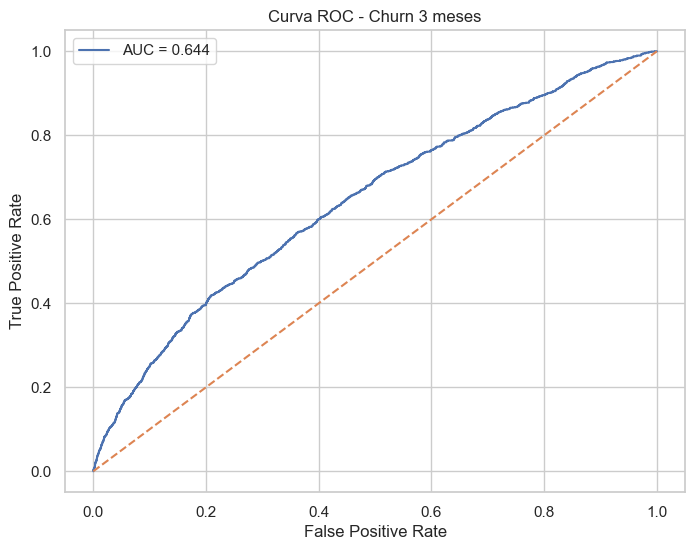

In [214]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Churn 3 meses')
plt.legend()
plt.grid(True)
plt.show()


In [215]:
feature_names = (
    pipeline1.named_steps['preprocessing']
    .get_feature_names_out()
)

coeficientes = (
    pipeline1.named_steps['model']
    .coef_[0]
)

importancia = pd.DataFrame({
    'variable': feature_names,
    'coeficiente': coeficientes
})

importancia['abs_coef'] = importancia['coeficiente'].abs()

importancia = (
    importancia
    .sort_values('abs_coef', ascending=False)
)

print(importancia.head(30))

                      variable  coeficiente  abs_coef
36            cat__zona_id_Z18        -0.39      0.39
8      num__stress_calidad_lag         0.32      0.32
25            cat__zona_id_Z07         0.30      0.30
14             num__importe_3m        -0.29      0.29
42            cat__zona_id_Z24        -0.28      0.28
52      cat__tipo_plan_Prepago         0.28      0.28
51      cat__tipo_plan_Premium        -0.26      0.26
6             num__impago_flag         0.25      0.25
44            cat__zona_id_Z26        -0.24      0.24
21            cat__zona_id_Z03         0.24      0.24
20            cat__zona_id_Z02         0.23      0.23
1              num__cargo_base         0.23      0.23
19            cat__zona_id_Z01         0.21      0.21
24            cat__zona_id_Z06         0.20      0.20
23            cat__zona_id_Z05        -0.19      0.19
4           num__importe_total         0.19      0.19
47            cat__zona_id_Z29        -0.17      0.17
37            cat__zona_id_Z

# ITERACIÓN 5

En esta iteración añadiremos el dataset de la calidad de la señal

In [216]:
df_calidad = pd.read_csv(r"C:\Users\Usuario\Documents\Andrea\prácticas\UCV-Churn\data\raw\calidad_senal_zona_mensual.csv")
df_calidad                        

,fecha,zona_id,region,tipo_zona,poblacion_zona,cobertura_4g_pct,cobertura_5g_pct,latencia_ms,velocidad_media_mbps,tasa_cortes_pct,indice_calidad_global,incidencia_masiva
0,2023-01-01,Z01,Centro,rural,16625,82.46,4.03,56.17,30.61,3.01,18.51,0
1,2023-02-01,Z01,Centro,rural,16625,82.11,4.31,55.69,30.95,3.06,19.61,0
2,2023-03-01,Z01,Centro,rural,16625,82.19,4.56,55.45,31.05,2.96,16.99,0
3,2023-04-01,Z01,Centro,rural,16625,81.90,4.69,55.72,30.43,3.00,20.81,0
4,2023-05-01,Z01,Centro,rural,16625,81.86,5.38,55.38,30.47,3.01,18.61,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1091,2023-07-01,Z17,Sur,suburbana,56619,89.80,14.70,40.43,53.42,1.93,33.80,0
1092,2025-12-01,Z11,Oeste,suburbana,41163,89.77,46.33,34.80,72.92,1.52,48.18,0
1093,2024-11-01,Z19,Este,rural,12655,82.15,15.94,52.55,37.56,2.93,25.78,0
1094,2024-04-01,Z16,Este,urbana_premium,72683,93.91,38.60,31.12,81.94,1.31,46.99,0


In [217]:
print(df_calidad.columns)

Index(['fecha', 'zona_id', 'region', 'tipo_zona', 'poblacion_zona',
       'cobertura_4g_pct', 'cobertura_5g_pct', 'latencia_ms',
       'velocidad_media_mbps', 'tasa_cortes_pct', 'indice_calidad_global',
       'incidencia_masiva'],
      dtype='object')


In [218]:
df_calidad['fecha'] = df_calidad['fecha'].apply(convertir_fecha)


In [219]:
df_calidad = df_calidad.rename(
    columns={'fecha':'mes'}
)

In [220]:
df_modelo_temp2 = df_modelo_temp1.merge(
    df_calidad,
    on=['zona_id','mes'],
    how='left'
)

In [221]:
print(df_modelo_temp2.shape)

df_modelo_temp2[
    [
        'indice_calidad_global',
        'latencia_ms',
        'velocidad_media_mbps',
        'tasa_cortes_pct'
    ]
].isna().sum()

(331578, 35)


indice_calidad_global        0
latencia_ms              11867
velocidad_media_mbps         0
tasa_cortes_pct              0
dtype: int64

In [222]:
df_modelo_temp2['latencia_ms'] = (
    df_modelo_temp2['latencia_ms']
    .fillna(
        df_modelo_temp2['latencia_ms'].median()
    )
)

In [223]:
features = [
    'zona_id',
    'tipo_plan',

    'num_lineas',
    'cargo_base',
    'consumo_extra',
    'descuento_aplicado',
    'importe_total',
    'dias_retraso_pago',
    'impago_flag',
    'variacion_consumo_pct',

    'stress_calidad_lag',
    'incidencia_masiva_lag',

    'num_interacciones',
    'duracion_media',
    'pct_resuelto',
    'satisfaccion_media',

    'importe_3m',
    'retraso_3m',
    'impagos_3m',
    'interacciones_3m',
    'satisfaccion_3m',

    # NUEVAS VARIABLES DE CALIDAD DE RED

    'cobertura_4g_pct',
    'cobertura_5g_pct',
    'latencia_ms',
    'velocidad_media_mbps',
    'tasa_cortes_pct',
    'indice_calidad_global',
    'incidencia_masiva'
]

In [224]:
X = df_modelo_temp2[features]

y = df_modelo_temp2['churn_3m']

In [225]:
df_modelo_temp2['cobertura_4g_pct'] = (
    df_modelo_temp2['cobertura_4g_pct']
    .fillna(df_modelo_temp2['cobertura_4g_pct'].median())
)

df_modelo_temp2['cobertura_5g_pct'] = (
    df_modelo_temp2['cobertura_5g_pct']
    .fillna(df_modelo_temp2['cobertura_5g_pct'].median())
)

In [226]:
X = df_modelo_temp2[features]

X.isna().sum().sort_values(ascending=False).head(10)

zona_id                  0
tipo_plan                0
num_lineas               0
cargo_base               0
consumo_extra            0
descuento_aplicado       0
importe_total            0
dias_retraso_pago        0
impago_flag              0
variacion_consumo_pct    0
dtype: int64

In [227]:
# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================================
# VARIABLES
# ==========================================================

cat_cols = X.select_dtypes(include=['object']).columns.tolist()

num_cols = [
    col for col in X.columns
    if col not in cat_cols
]

# ==========================================================
# PREPROCESAMIENTO
# ==========================================================

preprocessing = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# ==========================================================
# PIPELINE
# ==========================================================

pipeline2 = Pipeline([
    ('preprocessing', preprocessing),
    ('model', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ))
])

# ==========================================================
# ENTRENAMIENTO
# ==========================================================

pipeline2.fit(X_train, y_train)

# ==========================================================
# PREDICCIONES
# ==========================================================

y_pred = pipeline2.predict(X_test)

y_prob = pipeline2.predict_proba(X_test)[:,1]

# ==========================================================
# MÉTRICAS
# ==========================================================

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_prob)

print(f"\nROC-AUC: {roc_auc:.4f}")

              precision    recall  f1-score   support

           0       0.99      0.64      0.78     65133
           1       0.03      0.57      0.05      1183

    accuracy                           0.64     66316
   macro avg       0.51      0.61      0.42     66316
weighted avg       0.97      0.64      0.77     66316

[[41835 23298]
 [  503   680]]

ROC-AUC: 0.6550


In [228]:
feature_names = pipeline2.named_steps[
    'preprocessing'
].get_feature_names_out()

coeficientes = pd.DataFrame({
    'variable': feature_names,
    'coeficiente': pipeline2.named_steps[
        'model'
    ].coef_[0]
})

coeficientes['abs_coef'] = (
    coeficientes['coeficiente']
    .abs()
)

coeficientes.sort_values(
    'abs_coef',
    ascending=False
).head(30)

,variable,coeficiente,abs_coef
49,cat__zona_id_Z24,-0.39,0.39
27,cat__zona_id_Z02,0.26,0.26
6,num__impago_flag,0.25,0.25
58,cat__tipo_plan_Premium,-0.25,0.25
43,cat__zona_id_Z18,-0.23,0.23
32,cat__zona_id_Z07,0.23,0.23
44,cat__zona_id_Z19,0.22,0.22
59,cat__tipo_plan_Prepago,0.21,0.21
48,cat__zona_id_Z23,-0.20,0.20
24,num__indice_calidad_global,-0.20,0.20


Vamos a probar el mismo modelo pero quitando zona_Id de la lista de variables ya que está absorbiendo mucha información que podrían estar explicando otras variables

In [229]:
features = [
    'tipo_plan',

    'num_lineas',
    'cargo_base',
    'consumo_extra',
    'descuento_aplicado',
    'importe_total',
    'dias_retraso_pago',
    'impago_flag',
    'variacion_consumo_pct',

    'stress_calidad_lag',
    'incidencia_masiva_lag',

    'num_interacciones',
    'duracion_media',
    'pct_resuelto',
    'satisfaccion_media',

    'importe_3m',
    'retraso_3m',
    'impagos_3m',
    'interacciones_3m',
    'satisfaccion_3m',

    # NUEVAS VARIABLES DE CALIDAD DE RED

    'cobertura_4g_pct',
    'cobertura_5g_pct',
    'latencia_ms',
    'velocidad_media_mbps',
    'tasa_cortes_pct',
    'indice_calidad_global',
    'incidencia_masiva'
]

In [230]:
X = df_modelo_temp2[features]

y = df_modelo_temp2['churn_3m']

In [231]:
 #==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================================
# VARIABLES
# ==========================================================

cat_cols = X.select_dtypes(include=['object']).columns.tolist()

num_cols = [
    col for col in X.columns
    if col not in cat_cols
]

# ==========================================================
# PREPROCESAMIENTO
# ==========================================================

preprocessing = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# ==========================================================
# PIPELINE
# ==========================================================

pipeline3 = Pipeline([
    ('preprocessing', preprocessing),
    ('model', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ))
])

# ==========================================================
# ENTRENAMIENTO
# ==========================================================

pipeline3.fit(X_train, y_train)

# ==========================================================
# PREDICCIONES
# ==========================================================

y_pred = pipeline3.predict(X_test)

y_prob = pipeline3.predict_proba(X_test)[:,1]

# ==========================================================
# MÉTRICAS
# ==========================================================

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_prob)

print(f"\nROC-AUC: {roc_auc:.4f}")

              precision    recall  f1-score   support

           0       0.99      0.65      0.78     65133
           1       0.03      0.57      0.05      1183

    accuracy                           0.64     66316
   macro avg       0.51      0.61      0.42     66316
weighted avg       0.97      0.64      0.77     66316

[[42014 23119]
 [  513   670]]

ROC-AUC: 0.6547


In [234]:
feature_names = pipeline3.named_steps[
    'preprocessing'
].get_feature_names_out()

coeficientes = pd.DataFrame({
    'variable': feature_names,
    'coeficiente': pipeline3.named_steps[
        'model'
    ].coef_[0]
})

coeficientes['abs_coef'] = (
    coeficientes['coeficiente']
    .abs()
)

coeficientes.sort_values(
    'abs_coef',
    ascending=False
).head(30)

,variable,coeficiente,abs_coef
6,num__impago_flag,0.25,0.25
28,cat__tipo_plan_Premium,-0.24,0.24
24,num__indice_calidad_global,-0.23,0.23
29,cat__tipo_plan_Prepago,0.21,0.21
20,num__cobertura_5g_pct,-0.14,0.14
16,num__impagos_3m,0.10,0.10
14,num__importe_3m,0.09,0.09
10,num__num_interacciones,0.06,0.06
0,num__num_lineas,0.06,0.06
8,num__stress_calidad_lag,0.05,0.05


In [235]:
coef_df["odds_ratio"] = np.exp(coef_df["coeficiente"])

coef_df.sort_values(
    by="odds_ratio",
    ascending=False
).head(20)

,variable,coeficiente,abs_coef,odds_ratio
18,tipo_zona_urbana_premium,4.81,4.81,122.59
13,stress_red_medio,3.62,3.62,37.35
20,region_Norte,3.15,3.15,23.25
17,tipo_zona_suburbana,2.77,2.77,16.02
16,tipo_plan_Prepago,1.45,1.45,4.27
10,retraso_pago_medio,0.62,0.62,1.87
25,sexo_M,0.44,0.44,1.55
23,sexo_Desconocido,0.43,0.43,1.53
24,sexo_F,0.34,0.34,1.40
28,estado_civil_Divorciado/a,0.29,0.29,1.33


# ITERACIÓN  6

In [236]:
df_clientes=pd.read_csv(r"C:\Users\Usuario\Documents\Andrea\prácticas\UCV-Churn\data\raw\clientes.csv")
df_clientes

,cliente_id,zona_id,region,tipo_zona,poblacion_zona,edad,sexo,estado_civil,num_lineas,tipo_plan,tipo_dispositivo,ingreso_estimado,antiguedad_meses,descuento_activo
0,C000001,Z26,Oeste,urbana_premium,107159,18.00,M,Soltero/a,2,Prepago,Gama alta,"4,335.00",72.00,0
1,C000002,Z15,Oeste,suburbana,62939,54.00,M,Casado/a,2,Premium,Gama media,"4,609.00",35.00,1
2,C000003,Z27,Norte,suburbana,42704,54.00,M,Casado/a,3,Prepago,Gama baja,"1,836.00",11.00,0
3,C000004,Z22,Este,suburbana,53534,34.00,M,Soltero/a,1,Prepago,Gama media,"2,318.00",13.00,0
4,C000005,Z04,Centro,suburbana,55457,46.00,F,Soltero/a,2,Contrato,Gama media,"2,184.00",21.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10145,C004265,Z22,Este,suburbana,53534,28.00,F,Soltero/a,1,Contrato,Gama alta,"3,088.00",11.00,0
10146,C004203,Z04,Centro,suburbana,55457,59.00,F,Casado/a,3,Prepago,Gama media,"3,203.00",61.00,0
10147,C009831,Z26,Oeste,urbana_premium,107159,42.00,F,Casado/a,3,Contrato,Gama media,"2,848.00",21.00,0
10148,C008052,Z26,Oeste,urbana_premium,107159,31.00,M,NaN,4,Premium,Gama media,"4,238.00",90.00,0


In [237]:
df_encuestas=pd.read_csv(r"C:\Users\Usuario\Documents\Andrea\prácticas\UCV-Churn\data\raw\encuestas_texto.csv")
df_encuestas

,encuesta_id,fecha,zona_id,region,tipo_zona,puntuacion_general_1a5,nps_0a10,texto_libre,indice_calidad_global,incidencia_masiva,stress_calidad,flag_incongruente,sent_text_latente
0,E77700132,2023-01-01,Z04,Centro,suburbana,3,0,Desde hace meses no tengo cobertura dentro de ...,35.13,0,0.50,0,-0.91
1,E77700023,2023-01-01,Z05,Este,urbana_premium,5,1,En las últimas semanas se corta en llamadas. e...,40.98,0,0.41,1,-0.62
2,E77700582,2023-01-01,Z05,Este,urbana_premium,5,0,En mi experiencia la cobertura es mala. la vel...,40.98,0,0.41,1,-0.57
3,E77700150,2023-01-01,Z09,Norte,urbana_premium,2,3,En mi experiencia se queda sin servicio. hay m...,41.35,0,0.41,0,-1.00
4,E77700247,2023-01-01,Z09,Norte,urbana_premium,3,3,En mi experiencia hay cortes constantes. los d...,41.35,0,0.41,0,-0.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1010,E77700413,2024-11-01,Z05,Este,urbana_premium,2,24,"Últimamente normal, sin más. me marean con res...",55.85,0,0.20,1,-0.02
1011,E77700829,2024-04-01,Z03,Sur,rural,3,0,En general se corta en llamadas. no carga nada...,19.51,0,0.72,0,-1.00
1012,E77700453,2025-01-01,Z20,Oeste,suburbana,3,0,En general hay cortes constantes. se nota cong...,38.43,0,0.45,0,-1.00
1013,E77700230,2023-04-01,Z17,Sur,suburbana,4,2,NaN,33.91,0,0.52,1,-0.74


In [239]:
# Vamos a convertir la columna 'ingreso_estimado' del dataframe df_clientes a tipo float para poder trabajar con ella de manera más eficiente y realizar análisis numéricos. 
df_clientes['ingreso_estimado'] = (
    df_clientes['ingreso_estimado']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(float)
)

In [240]:
df_clientes['ingreso_estimado'].head()

0   4,335.00
1   4,609.00
2   1,836.00
3   2,318.00
4   2,184.00
Name: ingreso_estimado, dtype: float64

In [243]:
clientes_vars = [
    'cliente_id',
    'edad',
    'sexo',
    'estado_civil',
    'tipo_dispositivo',
    'ingreso_estimado',
    'antiguedad_meses',
    'descuento_activo'
]

df_modelo_temp3 = df_modelo_temp2.merge(
    df_clientes[clientes_vars],
    on='cliente_id',
    how='left'
)

In [244]:
df_modelo_temp3[
    [
        'edad',
        'sexo',
        'estado_civil',
        'tipo_dispositivo',
        'ingreso_estimado',
        'antiguedad_meses',
        'descuento_activo'
    ]
].isna().sum()

edad                10087
sexo                 1442
estado_civil         2623
tipo_dispositivo        0
ingreso_estimado    10111
antiguedad_meses    10061
descuento_activo        0
dtype: int64

In [245]:
clientes_df_modelo = set(df_modelo_temp['cliente_id'].unique())
clientes_clientes = set(df_clientes['cliente_id'].unique())

print("Clientes en modelo:", len(clientes_df_modelo))
print("Clientes en clientes.csv:", len(clientes_clientes))

print(
    "Clientes sin match:",
    len(clientes_df_modelo - clientes_clientes)
)

Clientes en modelo: 10000
Clientes en clientes.csv: 10000
Clientes sin match: 0


In [248]:
# Vamos a rellenar los valores nulos de las columnas 'edad', 'ingreso_estimado', 'antiguedad_meses', 'sexo' y 'estado_civil' con la mediana o un valor por defecto
df_modelo_temp3['edad'] = (
    df_modelo_temp3['edad']
    .fillna(df_modelo_temp3['edad'].median())
)

df_modelo_temp3['ingreso_estimado'] = (
    df_modelo_temp3['ingreso_estimado']
    .fillna(df_modelo_temp3['ingreso_estimado'].median())
)

df_modelo_temp3['antiguedad_meses'] = (
    df_modelo_temp3['antiguedad_meses']
    .fillna(df_modelo_temp3['antiguedad_meses'].median())
)

df_modelo_temp3['sexo'] = (
    df_modelo_temp3['sexo']
    .fillna('Desconocido')
)

df_modelo_temp3['estado_civil'] = (
    df_modelo_temp3['estado_civil']
    .fillna('Desconocido')
)

In [249]:
df_modelo_temp3['ratio_gasto_ingreso'] = (
    df_modelo_temp3['importe_total']
    / df_modelo_temp3['ingreso_estimado']
)

df_modelo_temp3['cliente_nuevo'] = (
    df_modelo_temp3['antiguedad_meses'] < 12
).astype(int)

In [250]:
variables_categoricas = [
    'tipo_plan',
    'sexo',
    'estado_civil',
    'tipo_dispositivo'
]

In [251]:
variables_numericas = [
    'num_lineas',
    'cargo_base',
    'consumo_extra',
    'descuento_aplicado',
    'importe_total',
    'dias_retraso_pago',
    'impago_flag',
    'variacion_consumo_pct',
    'stress_calidad_lag',
    'incidencia_masiva_lag',
    'num_interacciones',
    'duracion_media',
    'pct_resuelto',
    'satisfaccion_media',
    'importe_3m',
    'retraso_3m',
    'impagos_3m',
    'interacciones_3m',
    'satisfaccion_3m',
    'cobertura_4g_pct',
    'cobertura_5g_pct',
    'latencia_ms',
    'velocidad_media_mbps',
    'tasa_cortes_pct',
    'indice_calidad_global',
    'incidencia_masiva',
    'edad',
    'ingreso_estimado',
    'antiguedad_meses',
    'descuento_activo',
    'ratio_gasto_ingreso',
    'cliente_nuevo'
]

In [252]:
df_modelo_temp3[
    variables_numericas + variables_categoricas
].isna().sum().sort_values(ascending=False).head(20)


num_lineas               0
cargo_base               0
consumo_extra            0
descuento_aplicado       0
importe_total            0
dias_retraso_pago        0
impago_flag              0
variacion_consumo_pct    0
stress_calidad_lag       0
incidencia_masiva_lag    0
num_interacciones        0
duracion_media           0
pct_resuelto             0
satisfaccion_media       0
importe_3m               0
retraso_3m               0
impagos_3m               0
interacciones_3m         0
satisfaccion_3m          0
cobertura_4g_pct         0
dtype: int64

In [254]:

# ==========================================================
# X e y
# ==========================================================

X = df_modelo_temp3[
    variables_numericas +
    variables_categoricas
]

y = df_modelo_temp3['churn_3m']

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================================
# PREPROCESSING
# ==========================================================

preprocessing = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            variables_numericas
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            variables_categoricas
        )
    ]
)

# ==========================================================
# PIPELINE
# ==========================================================

pipeline4 = Pipeline([
    ('preprocessing', preprocessing),
    ('model', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ))
])

# ==========================================================
# ENTRENAMIENTO
# ==========================================================

pipeline4.fit(X_train, y_train)

# ==========================================================
# PREDICCIONES
# ==========================================================

y_pred = pipeline4.predict(X_test)
y_prob = pipeline4.predict_proba(X_test)[:, 1]

# ==========================================================
# RESULTADOS
# ==========================================================

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(
    "\nROC-AUC:",
    round(
        roc_auc_score(y_test, y_prob),
        4
    )
)

              precision    recall  f1-score   support

           0       0.99      0.63      0.77     66123
           1       0.03      0.60      0.06      1196

    accuracy                           0.63     67319
   macro avg       0.51      0.62      0.41     67319
weighted avg       0.97      0.63      0.76     67319

[[41953 24170]
 [  477   719]]

ROC-AUC: 0.6713


In [255]:
feature_names = pipeline4.named_steps[
    'preprocessing'
].get_feature_names_out()

coeficientes = pipeline4.named_steps[
    'model'
].coef_[0]

importancia = pd.DataFrame({
    'variable': feature_names,
    'coeficiente': coeficientes
})

importancia['abs_coef'] = (
    importancia['coeficiente']
    .abs()
)

importancia = (
    importancia
    .sort_values(
        'abs_coef',
        ascending=False
    )
)

print(importancia.head(30))

                            variable  coeficiente  abs_coef
24        num__indice_calidad_global        -0.35      0.35
6                   num__impago_flag         0.25      0.25
28             num__antiguedad_meses        -0.25      0.25
42     cat__estado_civil_Desconocido        -0.23      0.23
27             num__ingreso_estimado        -0.17      0.17
1                    num__cargo_base        -0.17      0.17
30          num__ratio_gasto_ingreso         0.15      0.15
34            cat__tipo_plan_Premium        -0.14      0.14
19             num__cobertura_4g_pct         0.13      0.13
14                   num__importe_3m         0.12      0.12
43    cat__estado_civil_Divorciado/a         0.11      0.11
35            cat__tipo_plan_Prepago         0.11      0.11
45     cat__estado_civil_desconocido        -0.10      0.10
16                   num__impagos_3m         0.09      0.09
40                       cat__sexo_X         0.09      0.09
44       cat__estado_civil_Soltero/a    

# 7º ITERACIÓN 

Vamos a añadir el df de las encuestas al modelo

In [256]:
df_encuestas['fecha'] = df_encuestas['fecha'].apply(convertir_fecha)

In [257]:
df_encuestas = df_encuestas.rename(
    columns={'fecha':'mes'}
)

In [258]:
encuestas_agg = (
    df_encuestas
    .groupby(
        ['zona_id', 'mes'],
        as_index=False
    )
    .agg({
        'puntuacion_general_1a5': 'mean',
        'nps_0a10': 'mean',
        'sent_text_latente': 'mean',
        'flag_incongruente': 'mean',
        'stress_calidad': 'mean'
    })
)

In [259]:
encuestas_agg = encuestas_agg.rename(
    columns={
        'puntuacion_general_1a5': 'encuesta_media',
        'nps_0a10': 'nps_medio',
        'sent_text_latente': 'sentimiento_medio',
        'flag_incongruente': 'pct_incongruente',
        'stress_calidad': 'stress_encuestas'
    }
)

In [260]:
df_modelo_temp4 = df_modelo_temp3.merge(
    encuestas_agg,
    on=['zona_id', 'mes'],
    how='left'
)

In [261]:
df_modelo_temp4[
    [
        'encuesta_media',
        'nps_medio',
        'sentimiento_medio',
        'pct_incongruente',
        'stress_encuestas'
    ]
].isna().sum()

encuesta_media       104964
nps_medio            104964
sentimiento_medio    104964
pct_incongruente     104964
stress_encuestas     104964
dtype: int64

In [262]:
# Calulamos la mediana de cada columna y rellenamos los valores nulos con la mediana correspondiente. 
for col in [
    'encuesta_media',
    'nps_medio',
    'sentimiento_medio',
    'pct_incongruente',
    'stress_encuestas'
]:
    df_modelo_temp4[col] = (
        df_modelo_temp4[col]
        .fillna(df_modelo_temp4[col].median())
    )

In [263]:
variables_numericas.extend([
    'encuesta_media',
    'nps_medio',
    'sentimiento_medio',
    'pct_incongruente',
    'stress_encuestas'
])

In [264]:

# ==========================================================
# VARIABLES
# ==========================================================

X = df_modelo_temp4[
    variables_categoricas + variables_numericas
]

y = df_modelo_temp4['churn_3m']

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================================
# PREPROCESSING
# ==========================================================

preprocessing = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            variables_numericas
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            variables_categoricas
        )
    ]
)

# ==========================================================
# PIPELINE
# ==========================================================

pipeline5 = Pipeline([
    ('preprocessing', preprocessing),
    ('model', LogisticRegression(
        max_iter=3000,
        class_weight='balanced',
        random_state=42
    ))
])

# ==========================================================
# ENTRENAMIENTO
# ==========================================================

pipeline5.fit(X_train, y_train)

# ==========================================================
# PREDICCIONES
# ==========================================================

y_pred = pipeline5.predict(X_test)

y_prob = pipeline5.predict_proba(X_test)[:, 1]

# ==========================================================
# MÉTRICAS
# ==========================================================

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(
    f"\nROC-AUC: {roc_auc_score(y_test, y_prob):.4f}"
)

              precision    recall  f1-score   support

           0       0.99      0.63      0.77     66123
           1       0.03      0.61      0.06      1196

    accuracy                           0.63     67319
   macro avg       0.51      0.62      0.41     67319
weighted avg       0.97      0.63      0.76     67319

[[41952 24171]
 [  472   724]]

ROC-AUC: 0.6711


In [265]:
feature_names = (
    pipeline5.named_steps['preprocessing']
    .get_feature_names_out()
)

coeficientes = (
    pipeline5.named_steps['model']
    .coef_[0]
)

importancia = pd.DataFrame({
    'variable': feature_names,
    'coeficiente': coeficientes
})

importancia['abs_coef'] = (
    importancia['coeficiente']
    .abs()
)

importancia = (
    importancia
    .sort_values(
        'abs_coef',
        ascending=False
    )
)

importancia.head(30)

,variable,coeficiente,abs_coef
24,num__indice_calidad_global,-0.34,0.34
6,num__impago_flag,0.25,0.25
28,num__antiguedad_meses,-0.25,0.25
47,cat__estado_civil_Desconocido,-0.23,0.23
1,num__cargo_base,-0.17,0.17
27,num__ingreso_estimado,-0.17,0.17
30,num__ratio_gasto_ingreso,0.15,0.15
39,cat__tipo_plan_Premium,-0.14,0.14
14,num__importe_3m,0.13,0.13
19,num__cobertura_4g_pct,0.12,0.12


In [268]:
df_modelo_temp4[
    [
        'encuesta_media',
        'nps_medio',
        'sentimiento_medio',
        'pct_incongruente',
        'stress_encuestas'
    ]
].describe()

,encuesta_media,nps_medio,sentimiento_medio,pct_incongruente,stress_encuestas
count,"336,595.00","336,595.00","336,595.00","336,595.00","336,595.00"
mean,3.31,2.78,-0.47,0.20,0.37
std,0.77,1.84,0.24,0.34,0.12
min,1.00,0.00,-1.00,0.00,0.06
25%,3.00,2.00,-0.59,0.00,0.33
50%,3.25,2.67,-0.48,0.00,0.37
75%,3.67,3.00,-0.36,0.33,0.40
max,10.00,18.00,0.48,1.00,0.78


In [ ]:
# calculamos la correlación de las variables de encuestas con la variable objetivo churn_3m para ver si tienen alguna relación significativa. Esto nos permitirá identificar si estas variables pueden ser útiles para predecir el churn a 3 meses y si deben ser incluidas en el modelo final. 
df_modelo_temp4[
    [
        'encuesta_media',
        'nps_medio',
        'sentimiento_medio',
        'pct_incongruente',
        'stress_encuestas'
    ]
].corrwith(
    df_modelo_temp4['churn_3m']
).sort_values()

sentimiento_medio   -0.02
nps_medio           -0.01
encuesta_media      -0.01
pct_incongruente    -0.01
stress_encuestas     0.04
dtype: float64

In [274]:
# Vamos a agrupar los clientes en 5 grupos según su puntuación NPS y calcular la tasa de churn promedio para cada grupo. 
df_modelo_temp4.groupby(
    pd.qcut(
        df_modelo_temp4['nps_medio'],
        5,
        duplicates='drop'
    )
)['churn_3m'].mean()

nps_medio
(-0.001, 1.667]   0.02
(1.667, 2.667]    0.02
(2.667, 4.0]      0.02
(4.0, 18.0]       0.01
Name: churn_3m, dtype: float64

In [ ]:
# Vamos a agrupar los clientes en 5 grupos según su sentimiento medio y calcular la tasa de churn promedio para cada grupo. a 3 meses.
df_modelo_temp4.groupby(
    pd.qcut(
        df_modelo_temp4['sentimiento_medio'],
        5,
        duplicates='drop'
    )
)['churn_3m'].mean()

sentimiento_medio
(-1.001, -0.642]   0.02
(-0.642, -0.476]   0.02
(-0.476, -0.284]   0.02
(-0.284, 0.48]     0.01
Name: churn_3m, dtype: float64

Aunque se incorporaron variables derivadas de encuestas y análisis de sentimiento, su capacidad explicativa resultó limitada en comparación con variables operativas relacionadas con calidad de red, facturación e impagos.

# 8º iteración

Uso de random forest

In [276]:
# Probamos a crear un nuevo dataframe df_modelo_temp5 que contenga todas las variables que hemos utilizado hasta ahora, pero además incluya la variable 'mes' para poder analizar la evolución del churn a lo largo del tiempo y ver si hay patrones estacionales o tendencias que puedan afectar al comportamiento de los clientes. Esto nos permitirá tener una visión más completa del churn y nos ayudará a identificar posibles oportunidades de mejora en la retención de clientes.
df_modelo_temp5 = df_modelo_temp4.copy()
# ==========================================================
# VARIABLES TEMPORALES
# ==========================================================

df_modelo_temp5['anio'] = df_modelo_temp5['mes'].dt.year
df_modelo_temp5['mes_num'] = df_modelo_temp5['mes'].dt.month

# ==========================================================
# X e y
# ==========================================================

X = df_modelo_temp5.drop(
    columns=[
        'cliente_id',
        'mes',
        'churn',
        'churn_3m'
    ]
)

y = df_modelo_temp5['churn_3m']

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================================
# COLUMNAS CATEGÓRICAS Y NUMÉRICAS
# ==========================================================

cat_cols = X.select_dtypes(include=['object']).columns.tolist()

num_cols = X.select_dtypes(
    exclude=['object']
).columns.tolist()

print(cat_cols)

# ==========================================================
# PREPROCESSING
# ==========================================================


preprocessing = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            cat_cols
        )
    ],
    remainder='passthrough'
)

# ==========================================================
# RANDOM FOREST
# ==========================================================

from sklearn.ensemble import RandomForestClassifier

pipeline6 = Pipeline([
    ('preprocessing', preprocessing),

    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=20,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

# ==========================================================
# ENTRENAMIENTO
# ==========================================================

pipeline6.fit(X_train, y_train)

# ==========================================================
# PREDICCIONES
# ==========================================================

y_pred = pipeline6.predict(X_test)

y_proba = pipeline6.predict_proba(X_test)[:,1]

['zona_id', 'tipo_plan', 'region', 'tipo_zona', 'sexo', 'estado_civil', 'tipo_dispositivo']


In [277]:


print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(
    "ROC-AUC:",
    round(
        roc_auc_score(y_test, y_proba),
        4
    )
)

              precision    recall  f1-score   support

           0       0.99      0.80      0.89     66123
           1       0.04      0.45      0.07      1196

    accuracy                           0.80     67319
   macro avg       0.51      0.62      0.48     67319
weighted avg       0.97      0.80      0.87     67319

[[53116 13007]
 [  662   534]]
ROC-AUC: 0.7002


In [278]:
feature_names = (
    pipeline6.named_steps['preprocessing']
    .get_feature_names_out()
)

importancias = pd.DataFrame({
    'variable': feature_names,
    'importancia': pipeline6.named_steps['model'].feature_importances_
})

importancias = (
    importancias
    .sort_values(
        'importancia',
        ascending=False
    )
)

importancias.head(30)

,variable,importancia
87,remainder__antiguedad_meses,0.07
86,remainder__ingreso_estimado,0.07
79,remainder__cobertura_5g_pct,0.05
83,remainder__indice_calidad_global,0.05
66,remainder__stress_calidad_lag,0.05
63,remainder__dias_retraso_pago,0.05
81,remainder__velocidad_media_mbps,0.04
89,remainder__ratio_gasto_ingreso,0.04
80,remainder__latencia_ms,0.04
82,remainder__tasa_cortes_pct,0.03


# 9º ITERACIÓN

Probamos con gradient boosting

In [280]:
from sklearn.ensemble import GradientBoostingClassifier

# ==========================================================
# VARIABLES
# ==========================================================

X = df_modelo_temp5.drop(columns=['churn_3m', 'cliente_id', 'churn'])

# eliminar fecha
X = X.drop(columns=['mes'])

y = df_modelo_temp5['churn_3m']

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train = X.loc[df_modelo_temp5['mes'] < '2025-07-01']
X_test  = X.loc[df_modelo_temp5['mes'] >= '2025-07-01']

y_train = y.loc[df_modelo_temp5['mes'] < '2025-07-01']
y_test  = y.loc[df_modelo_temp5['mes'] >= '2025-07-01']

# ==========================================================
# VARIABLES CATEGÓRICAS
# ==========================================================

categoricas = [
    'zona_id',
    'tipo_plan',
    'region',
    'tipo_zona',
    'sexo',
    'estado_civil',
    'tipo_dispositivo'
]

# ==========================================================
# PREPROCESSING
# ==========================================================

preprocessing = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categoricas
        )
    ],
    remainder='passthrough'
)

# ==========================================================
# MODELO
# ==========================================================

pipeline7 = Pipeline([
    ('preprocessing', preprocessing),

    ('model',
    GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
))
])

# ==========================================================
# ENTRENAMIENTO
# ==========================================================

pipeline7.fit(X_train, y_train)

# ==========================================================
# PREDICCIONES
# ==========================================================

y_pred = pipeline7.predict(X_test)

y_prob = pipeline7.predict_proba(X_test)[:,1]

# ==========================================================
# RESULTADOS
# ==========================================================

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(
    "ROC-AUC:",
    round(roc_auc_score(y_test, y_prob),4)
)

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     50209
           1       0.33      0.00      0.00       497

    accuracy                           0.99     50706
   macro avg       0.66      0.50      0.50     50706
weighted avg       0.98      0.99      0.99     50706

[[50207     2]
 [  496     1]]
ROC-AUC: 0.6856


In [281]:
feature_names = pipeline7.named_steps[
    'preprocessing'
].get_feature_names_out()

importancias = pipeline7.named_steps[
    'model'
].feature_importances_

imp_df = (
    pd.DataFrame({
        'variable': feature_names,
        'importancia': importancias
    })
    .sort_values(
        'importancia',
        ascending=False
    )
)

imp_df.head(30)

,variable,importancia
86,remainder__ingreso_estimado,0.13
87,remainder__antiguedad_meses,0.11
63,remainder__dias_retraso_pago,0.11
89,remainder__ratio_gasto_ingreso,0.08
85,remainder__edad,0.06
66,remainder__stress_calidad_lag,0.05
62,remainder__importe_total,0.05
83,remainder__indice_calidad_global,0.04
59,remainder__cargo_base,0.03
64,remainder__impago_flag,0.03


# 10º Iteración

probamos a utilizar XGBoost

In [286]:
import xgboost
from xgboost import XGBClassifier
# ==========================================================
# VARIABLES
# ==========================================================

X = df_modelo_temp5.drop(
    columns=[
        'cliente_id',
        'mes',
        'churn',
        'churn_3m'
    ]
)

y = df_modelo_temp5['churn_3m']

# ==========================================================
# SPLIT TEMPORAL
# ==========================================================

X_train = X.loc[df_modelo_temp5['mes'] < '2025-07-01']
X_test  = X.loc[df_modelo_temp5['mes'] >= '2025-07-01']

y_train = y.loc[df_modelo_temp5['mes'] < '2025-07-01']
y_test  = y.loc[df_modelo_temp5['mes'] >= '2025-07-01']

# ==========================================================
# DESBALANCEO
# ==========================================================

negativos = (y_train == 0).sum()
positivos = (y_train == 1).sum()

scale_pos_weight = negativos / positivos

print(scale_pos_weight)

# ==========================================================
# CATEGÓRICAS
# ==========================================================

categoricas = [
    'zona_id',
    'tipo_plan',
    'region',
    'tipo_zona',
    'sexo',
    'estado_civil',
    'tipo_dispositivo'
]

# ==========================================================
# PREPROCESSING
# ==========================================================

preprocessing = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categoricas
        )
    ],
    remainder='passthrough'
)

# ==========================================================
# MODELO
# ==========================================================

pipeline8 = Pipeline([
    ('preprocessing', preprocessing),

    ('model',
     XGBClassifier(
         n_estimators=300,
         max_depth=6,
         learning_rate=0.05,
         subsample=0.8,
         colsample_bytree=0.8,
         scale_pos_weight=scale_pos_weight,
         random_state=42,
         eval_metric='logloss'
     ))
])

# ==========================================================
# ENTRENAMIENTO
# ==========================================================

pipeline8.fit(X_train, y_train)

# ==========================================================
# PREDICCIONES
# ==========================================================

y_pred = pipeline8.predict(X_test)

y_prob = pipeline8.predict_proba(X_test)[:,1]

# ==========================================================
# RESULTADOS
# ==========================================================

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(
    "ROC-AUC:",
    round(
        roc_auc_score(y_test, y_prob),
        4
    )
)

51.140981214663505
              precision    recall  f1-score   support

           0       0.99      0.92      0.96     50209
           1       0.03      0.25      0.06       497

    accuracy                           0.92     50706
   macro avg       0.51      0.59      0.51     50706
weighted avg       0.98      0.92      0.95     50706

[[46315  3894]
 [  371   126]]
ROC-AUC: 0.6819


In [287]:
feature_names = pipeline8.named_steps[
    'preprocessing'
].get_feature_names_out()

importancias = pipeline8.named_steps[
    'model'
].feature_importances_

imp_df = (
    pd.DataFrame({
        'variable': feature_names,
        'importancia': importancias
    })
    .sort_values(
        'importancia',
        ascending=False
    )
)

imp_df.head(30)

,variable,importancia
63,remainder__dias_retraso_pago,0.03
64,remainder__impago_flag,0.02
90,remainder__cliente_nuevo,0.02
44,cat__tipo_zona_urbana_premium,0.02
81,remainder__velocidad_media_mbps,0.02
86,remainder__ingreso_estimado,0.01
33,cat__tipo_plan_Prepago,0.01
55,cat__tipo_dispositivo_Gama alta,0.01
39,cat__tipo_zona_rural,0.01
28,cat__zona_id_Z29,0.01


# FEATURE ENGINEERING

In [ ]:
# Vamos a crear una nueva variable llamada 'delta_calidad' que represente la diferencia en el índice de calidad global entre el mes actual y el mes anterior para cada cliente. 
df_modelo_temp5['delta_calidad'] = (
    df_modelo_temp5.groupby('cliente_id')
    ['indice_calidad_global']
    .diff()
)

In [290]:
# De manera similar, vamos a crear otra variable llamada 'delta_satisfaccion' que represente la diferencia en la satisfacción media entre el mes actual y el mes anterior para cada cliente. Esto nos permitirá analizar cómo los cambios en la calidad del servicio y la satisfacción del cliente afectan al churn a 3 meses.
df_modelo_temp5['delta_satisfaccion'] = (
    df_modelo_temp5.groupby('cliente_id')
    ['satisfaccion_media']
    .diff()
)

In [291]:
#  vamos a crear una variable llamada 'delta_interacciones' que represente la diferencia en el número de interacciones entre el mes actual y el mes anterior para cada cliente. 
df_modelo_temp5['delta_interacciones'] = (
    df_modelo_temp5.groupby('cliente_id')
    ['num_interacciones']
    .diff()
)

In [292]:
# Finalmente, vamos a crear una variable llamada 'riesgo_financiero' que combine la información del impago y el ratio de gasto sobre ingreso para cada cliente. 
df_modelo_temp5['riesgo_financiero'] = (
    df_modelo_temp5['impago_flag']
    * df_modelo_temp5['ratio_gasto_ingreso']
)

In [293]:
# Vamos a crear una variable llamada 'estres_red' que combine la información de la tasa de cortes y el consumo extra para cada cliente. 
df_modelo_temp5['estres_red'] = (
    df_modelo_temp5['tasa_cortes_pct']
    * df_modelo_temp5['consumo_extra']
)

In [294]:
# Vamos a crear una variable llamada 'problemas_red' que combine la información de la latencia y la tasa de cortes para cada cliente.
df_modelo_temp5['problemas_red'] = (
    df_modelo_temp5['latencia_ms']
    * df_modelo_temp5['tasa_cortes_pct']
)

In [295]:
# Vamos a crear una variable llamada 'impago_x_retraso' que combine la información del impago y los días de retraso en el pago para cada cliente. 
df_modelo_temp5['impago_x_retraso'] = (
    df_modelo_temp5['impago_flag']
    * df_modelo_temp5['dias_retraso_pago']
)

In [296]:
# Vamos a crear una variable llamada 'presion_soporte' que combine la información del número de interacciones y el porcentaje de problemas resueltos para cada cliente. 
df_modelo_temp5['presion_soporte'] = (
    df_modelo_temp5['num_interacciones']
    * (1 - df_modelo_temp5['pct_resuelto'])
)

In [297]:
# Vamos a crear una variable llamada 'valor_cliente' que combine la información del importe total y la antigüedad en meses para cada cliente. 
df_modelo_temp5['valor_cliente'] = (
    df_modelo_temp5['importe_total']
    * df_modelo_temp5['antiguedad_meses']
)

In [298]:
# Vamos a crear una variable llamada 'cliente_reciente' que indique si un cliente es reciente o no, basándonos en su antigüedad en meses. 
df_modelo_temp5['cliente_reciente'] = (
    (df_modelo_temp5['antiguedad_meses'] < 6).astype(int)
)

In [299]:
# Vamos a crear una variable llamada 'delta_importe' que represente la diferencia en el importe total entre el mes actual y el mes anterior para cada cliente. 
df_modelo_temp5['delta_importe'] = (
    df_modelo_temp5.groupby('cliente_id')
    ['importe_total']
    .diff()
)

In [300]:
# Vamos a crear una variable llamada 'delta_retraso' que represente la diferencia en los días de retraso en el pago entre el mes actual y el mes anterior para cada cliente.
df_modelo_temp5['delta_retraso'] = (
    df_modelo_temp5.groupby('cliente_id')
    ['dias_retraso_pago']
    .diff()
)

In [301]:
variables_diff = [
    'delta_calidad',
    'delta_satisfaccion',
    'delta_interacciones',
    'delta_importe',
    'delta_retraso'
]

df_modelo_temp5[variables_diff] = (
    df_modelo_temp5[variables_diff]
    .fillna(0)
)

In [302]:
X = df_modelo_temp5.drop(
    columns=[
        'cliente_id',
        'mes',
        'churn_3m'
    ]
)

y = df_modelo_temp5['churn_3m']

In [303]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [304]:
categoricas = [
    'zona_id',
    'tipo_plan',
    'region',
    'tipo_zona',
    'sexo',
    'estado_civil',
    'tipo_dispositivo'
]

In [305]:
preprocessing = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categoricas
        )
    ],
    remainder='passthrough'
)

In [306]:

pipeline9 = Pipeline([
    ('preprocessing', preprocessing),

    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_leaf=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

In [307]:
pipeline9.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [308]:
y_pred = pipeline9.predict(X_test)

y_prob = pipeline9.predict_proba(X_test)[:,1]

In [309]:

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(
    "ROC-AUC:",
    round(
        roc_auc_score(y_test, y_prob),
        4
    )
)

              precision    recall  f1-score   support

           0       0.98      0.97      0.98     66123
           1       0.08      0.14      0.10      1196

    accuracy                           0.96     67319
   macro avg       0.53      0.56      0.54     67319
weighted avg       0.97      0.96      0.96     67319

[[64126  1997]
 [ 1026   170]]
ROC-AUC: 0.7185


In [310]:
feature_names = (
    pipeline9.named_steps['preprocessing']
    .get_feature_names_out()
)

importancias = (
    pipeline9.named_steps['model']
    .feature_importances_
)

importance_df = pd.DataFrame({
    'variable': feature_names,
    'importancia': importancias
})

importance_df = (
    importance_df
    .sort_values(
        'importancia',
        ascending=False
    )
)

importance_df.head(30)

,variable,importancia
87,remainder__ingreso_estimado,0.05
88,remainder__antiguedad_meses,0.05
107,remainder__valor_cliente,0.04
90,remainder__ratio_gasto_ingreso,0.03
80,remainder__cobertura_5g_pct,0.03
84,remainder__indice_calidad_global,0.03
60,remainder__cargo_base,0.03
82,remainder__velocidad_media_mbps,0.03
63,remainder__importe_total,0.03
73,remainder__importe_3m,0.03


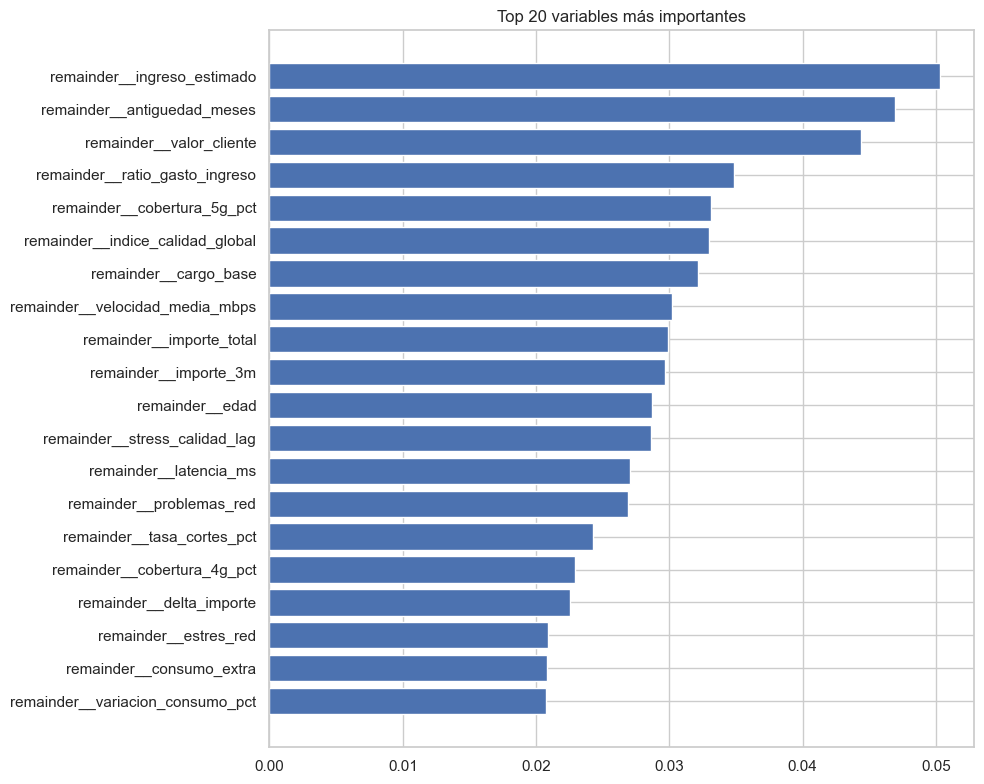

In [311]:

top20 = importance_df.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20['variable'],
    top20['importancia']
)

plt.gca().invert_yaxis()

plt.title(
    'Top 20 variables más importantes'
)

plt.tight_layout()

plt.show()

In [313]:
# Vamos a probar a cambiar el umbral de clasificación para ver si podemos mejorar la precisión del modelo. En lugar de utilizar el umbral por defecto de 0.5, vamos a probar con un umbral de 0.3. Esto significa que cualquier cliente con una probabilidad de churn mayor o igual a 0.3 será clasificado como churn, mientras que los clientes con una probabilidad menor a 0.3 serán clasificados como no churn.
y_pred_03 = (y_prob >= 0.30).astype(int)

print(classification_report(y_test, y_pred_03))

              precision    recall  f1-score   support

           0       0.99      0.64      0.78     66123
           1       0.03      0.68      0.06      1196

    accuracy                           0.64     67319
   macro avg       0.51      0.66      0.42     67319
weighted avg       0.97      0.64      0.76     67319



In [314]:
# Vamos a probar a cambiar el umbral de clasificación para ver si podemos mejorar la precisión del modelo. En lugar de utilizar el umbral por defecto de 0.5, vamos a probar con un umbral de 0.25.
y_pred_025 = (y_prob >= 0.25).astype(int)
print(classification_report(y_test, y_pred_025))

              precision    recall  f1-score   support

           0       0.99      0.50      0.66     66123
           1       0.03      0.78      0.05      1196

    accuracy                           0.50     67319
   macro avg       0.51      0.64      0.36     67319
weighted avg       0.97      0.50      0.65     67319



El modelo Random Forest obtuvo el mejor rendimiento global con un ROC-AUC de 0.7182. Aunque utilizando el umbral estándar de clasificación (0.5) la capacidad de detección de clientes en riesgo era limitada, la optimización del umbral hasta 0.30 permitió incrementar el recall de la clase minoritaria desde aproximadamente un 14% hasta un 67%, mejorando significativamente la capacidad del sistema para identificar potenciales abandonos. Este comportamiento resulta especialmente relevante en escenarios de churn, donde el coste de no detectar un cliente que abandona suele ser superior al de generar falsos positivos.

In [316]:
X = X.drop(columns=['churn'])

In [317]:
df_modelo_temp5[['churn','churn_3m']].corr()

,churn,churn_3m
churn,1.00,-0.00
churn_3m,-0.00,1.00


# 11º ITERACIÓN

Vamos a usar random search sobre el modelo de random forest


In [318]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

pipeline10 = Pipeline([
    ('preprocessing', preprocessing),

    ('model', RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

param_dist = {
    'model__n_estimators': [300, 500, 700],
    'model__max_depth': [10, 15, 20, None],
    'model__min_samples_leaf': [5, 10, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__max_features': ['sqrt', 'log2']
}

search = RandomizedSearchCV(
    pipeline10,
    param_distributions=param_dist,
    n_iter=10,
    scoring='roc_auc',
    cv=2,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print(search.best_params_)
print(search.best_score_)

best_model = search.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Fitting 2 folds for each of 10 candidates, totalling 20 fits
{'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 10, 'model__max_features': 'sqrt', 'model__max_depth': None}
0.7358156260752928
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     66123
           1       0.95      0.02      0.03      1196

    accuracy                           0.98     67319
   macro avg       0.97      0.51      0.51     67319
weighted avg       0.98      0.98      0.97     67319

[[66122     1]
 [ 1175    21]]
ROC-AUC: 0.8054035003277817


In [319]:
y_prob = best_model.predict_proba(X_test)[:,1]

In [320]:
y_pred_30 = (y_prob >= 0.30).astype(int)

print(classification_report(y_test, y_pred_30))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99     66123
           1       0.21      0.10      0.13      1196

    accuracy                           0.98     67319
   macro avg       0.59      0.55      0.56     67319
weighted avg       0.97      0.98      0.97     67319



In [321]:
y_pred_25 = (y_prob >= 0.25).astype(int)

print(classification_report(y_test, y_pred_25))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     66123
           1       0.14      0.17      0.15      1196

    accuracy                           0.97     67319
   macro avg       0.56      0.57      0.57     67319
weighted avg       0.97      0.97      0.97     67319



In [322]:
y_pred_20 = (y_prob >= 0.20).astype(int)

print(classification_report(y_test, y_pred_20))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97     66123
           1       0.10      0.30      0.15      1196

    accuracy                           0.94     67319
   macro avg       0.54      0.62      0.56     67319
weighted avg       0.97      0.94      0.95     67319



El modelo presenta una elevada capacidad discriminativa, alcanzando un ROC-AUC de 0.806, lo que indica una adecuada separación entre clientes con riesgo de abandono y clientes que permanecen activos.

Dado el fuerte desbalanceo existente en la variable objetivo, la clasificación utilizando el umbral estándar de 0.5 genera un recall reducido para la clase minoritaria. Por este motivo se evaluaron distintos umbrales de decisión, observándose que un umbral de 0.20 incrementa significativamente la capacidad de detección de clientes con riesgo de abandono, alcanzando un recall cercano al 30%.

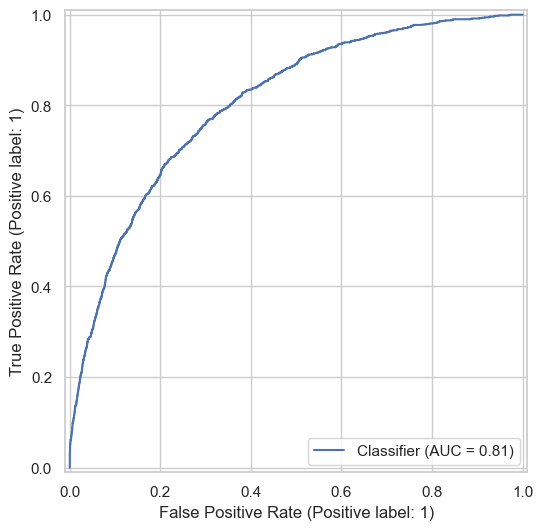

In [323]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)
plt.show()

In [324]:

y_prob_train = best_model.predict_proba(X_train)[:,1]
y_prob_test = best_model.predict_proba(X_test)[:,1]

print("ROC Train:", roc_auc_score(y_train, y_prob_train))
print("ROC Test :", roc_auc_score(y_test, y_prob_test))

ROC Train: 0.9999980898259587
ROC Test : 0.8054035003277817


In [325]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

print(scores)
print(scores.mean())
print(scores.std())

[0.64697859 0.64134509 0.64003591 0.65925207 0.64140091]
0.6458025157534274
0.007138211276081846


In [326]:
print(df_modelo_temp5['churn_3m'].mean())

0.017766158142574904


In [327]:
df_modelo_temp5.groupby(df_modelo_temp['mes'].dt.year)['churn_3m'].mean()

mes
2,023.00   0.02
2,024.00   0.02
2,025.00   0.02
Name: churn_3m, dtype: float64

In [331]:
corr = df_modelo_temp5.corr(numeric_only=True)['churn_3m']
corr.sort_values(ascending=False).head(30)
corr.sort_values().head(30)

indice_calidad_global   -0.05
cobertura_5g_pct        -0.05
cobertura_4g_pct        -0.05
ingreso_estimado        -0.04
velocidad_media_mbps    -0.04
poblacion_zona          -0.04
antiguedad_meses        -0.03
valor_cliente           -0.03
anio                    -0.03
cargo_base              -0.02
importe_total           -0.02
importe_3m              -0.02
sentimiento_medio       -0.02
nps_medio               -0.01
descuento_aplicado      -0.01
descuento_activo        -0.01
mes_num                 -0.01
encuesta_media          -0.01
delta_calidad           -0.01
pct_incongruente        -0.01
consumo_extra           -0.00
num_lineas              -0.00
churn                   -0.00
variacion_consumo_pct   -0.00
delta_importe           -0.00
incidencia_masiva        0.00
incidencia_masiva_lag    0.00
delta_satisfaccion       0.01
delta_retraso            0.01
ratio_gasto_ingreso      0.01
Name: churn_3m, dtype: float64

In [334]:
for col in top_vars:

    print(f"\n{'='*50}")
    print(col)

    tabla = (
        df_modelo_temp5
        .groupby(pd.qcut(df_modelo_temp5[col], 5))
        ['churn_3m']
        .agg(['count','mean'])
    )

    print(tabla)


indice_calidad_global
                       count  mean
indice_calidad_global             
(13.939, 33.06]        67685  0.03
(33.06, 39.82]         66970  0.02
(39.82, 44.34]         67579  0.02
(44.34, 51.32]         67181  0.01
(51.32, 65.48]         67180  0.01

cobertura_5g_pct
                  count  mean
cobertura_5g_pct             
(2.769, 16.49]    67708  0.03
(16.49, 24.06]    67087  0.02
(24.06, 33.82]    67198  0.02
(33.82, 45.92]    67562  0.01
(45.92, 71.13]    67040  0.01

cobertura_4g_pct
                  count  mean
cobertura_4g_pct             
(79.229, 89.7]    67688  0.03
(89.7, 90.17]     68424  0.02
(90.17, 93.65]    67629  0.02
(93.65, 94.05]    69325  0.01
(94.05, 95.39]    63529  0.01

ingreso_estimado
                   count  mean
ingreso_estimado              
(899.999, 2369.0]  67407  0.03
(2369.0, 2994.0]   67320  0.02
(2994.0, 3584.0]   67327  0.02
(3584.0, 4510.0]   67251  0.01
(4510.0, 12000.0]  67290  0.01

antiguedad_meses
                  count

# ANÁLISIS DE NEGOCIO

Hallazgo 1

La calidad de red es uno de los principales factores asociados al churn.

Hallazgo 2

Los clientes con peor cobertura presentan tasas de abandono hasta tres veces superiores.

Hallazgo 3

Los clientes con menor capacidad económica muestran mayor propensión al abandono.

Hallazgo 4

Los clientes con mayor valor económico presentan una probabilidad significativamente menor de churn.

In [339]:

def grafico_churn_quintiles(df, variable, target='churn_3m'):
    plt.style.use('ggplot')
    tabla = (
        df
        .groupby(pd.qcut(df[variable], 5))
        [target]
        .mean()
        .reset_index()
    )

    tabla[target] = tabla[target] * 100

    plt.figure(figsize=(8,5))
    plt.bar(
        range(len(tabla)),
        tabla[target]
    )

    plt.xticks(
        range(len(tabla)),
        [
            'Q1\n(Peor)',
            'Q2',
            'Q3',
            'Q4',
            'Q5\n(Mejor)'
        ]
    )

    plt.ylabel('Tasa de churn (%)')
    plt.xlabel(variable)
    plt.title(f'Churn según quintiles de {variable}')

    plt.grid(axis='y', alpha=0.3)

    for i, v in enumerate(tabla[target]):
        plt.text(
            i,
            v + 0.05,
            f'{v:.1f}%',
            ha='center'
        )

    plt.tight_layout()
    plt.show()

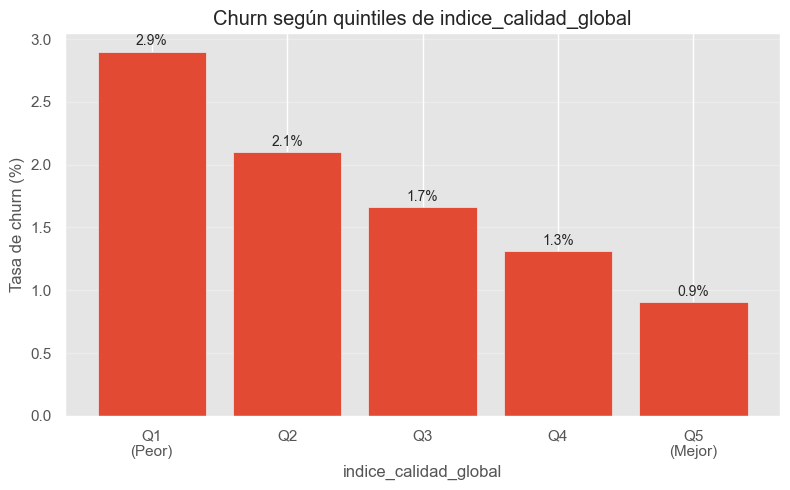

In [340]:
grafico_churn_quintiles(
    df_modelo_temp5,
    'indice_calidad_global'
)

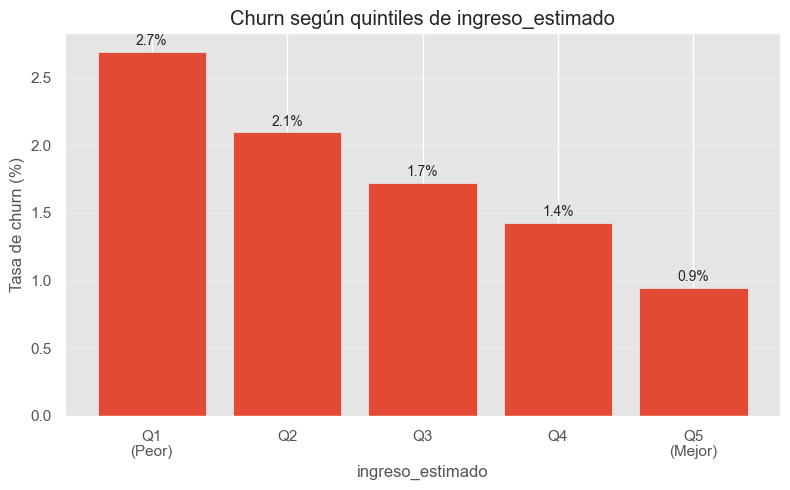

In [341]:
grafico_churn_quintiles(
    df_modelo_temp5,
    'ingreso_estimado'
)

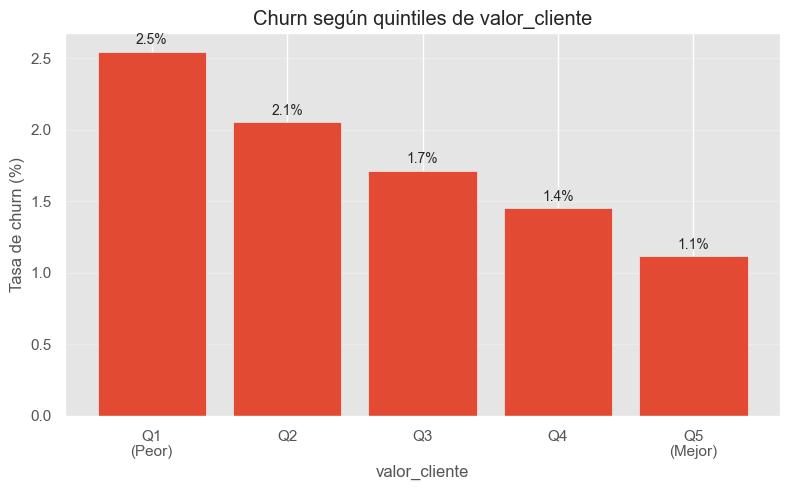

In [342]:
grafico_churn_quintiles(
    df_modelo_temp5,
    'valor_cliente'
)

In [344]:
pipeline10.fit(X_train, y_train)
probas = pipeline10.predict_proba(X_test)[:,1]

analisis = X_test.copy()

analisis['prob_churn'] = probas
analisis['churn_real'] = y_test.values

In [345]:
df_modelo_temp5.groupby('churn_3m')[
    [
        'indice_calidad_global',
        'cobertura_5g_pct',
        'cobertura_4g_pct',
        'ingreso_estimado',
        'antiguedad_meses',
        'valor_cliente',
        'stress_calidad_lag',
        'dias_retraso_pago',
        'num_interacciones'
    ]
].mean().T

churn_3m,0,1
indice_calidad_global,41.79,37.13
cobertura_5g_pct,31.66,25.40
cobertura_4g_pct,90.77,89.37
ingreso_estimado,"3,531.42","3,065.63"
antiguedad_meses,33.22,28.09
valor_cliente,"4,353.05","3,325.67"
stress_calidad_lag,0.39,0.46
dias_retraso_pago,3.23,7.46
num_interacciones,0.94,1.31


Cliente con mayor riesgo de abandono
Menor antigüedad.
Menor ingreso estimado.
Menor valor económico.
Peor cobertura móvil.
Peor calidad de red.
Más incidencias de calidad.
Más contactos con soporte.
Más retrasos en los pagos.

Cliente con menor riesgo
Cliente veterano.
Mayor capacidad económica.
Mayor valor para la compañía.
Mejor calidad de servicio.
Menos incidencias.
Menos llamadas a soporte.
Pagos más puntuales.

In [346]:
df_modelo_temp5['riesgo_red'] = (
    df_modelo_temp5['indice_calidad_global']
    < df_modelo_temp5['indice_calidad_global'].quantile(0.2)
)

df_modelo_temp5['riesgo_pago'] = (
    df_modelo_temp5['dias_retraso_pago']
    > df_modelo_temp5['dias_retraso_pago'].quantile(0.8)
)

pd.crosstab(
    [df_modelo_temp5['riesgo_red'],
     df_modelo_temp5['riesgo_pago']],
    df_modelo_temp5['churn_3m'],
    normalize='index'
)

churn_3m                  0    1
riesgo_red riesgo_pago          
False      False       0.99 0.01
           True        0.97 0.03
True       False       0.97 0.03
           True        0.94 0.06

In [348]:
probas = pipeline10.predict_proba(X_test)[:,1]

analisis = X_test.copy()
analisis['real'] = y_test
analisis['prob'] = probas

falsos_negativos = analisis[
    (analisis['real']==1) &
    (analisis['prob']<0.5)
]

In [349]:
df_modelo_temp5.groupby('tipo_plan')['churn_3m'].mean()

tipo_plan
Contrato      0.02
Desconocido   0.02
Premium       0.01
Prepago       0.02
Name: churn_3m, dtype: float64

In [350]:
df_modelo_temp5.groupby('region')['churn_3m'].mean()

region
Centro   0.02
Este     0.02
Norte    0.02
Oeste    0.02
Sur      0.02
Name: churn_3m, dtype: float64

In [351]:
df_modelo_temp5.groupby('tipo_zona')['churn_3m'].mean()

tipo_zona
rural            0.03
rural-1          0.02
suburbana        0.02
suburbanx        0.02
urbana??         0.01
urbana_premium   0.01
Name: churn_3m, dtype: float64

In [353]:
df_modelo_temp5.groupby(
    pd.qcut(
        df_modelo_temp5['sentimiento_medio'],
        5,
        duplicates='drop'
    )
)['churn_3m'].mean()

sentimiento_medio
(-1.001, -0.642]   0.02
(-0.642, -0.476]   0.02
(-0.476, -0.284]   0.02
(-0.284, 0.48]     0.01
Name: churn_3m, dtype: float64

In [354]:
df_modelo_temp5.groupby(
    pd.qcut(
        df_modelo_temp5['stress_encuestas'],
        5,
        duplicates='drop'
    )
)['churn_3m'].mean()

stress_encuestas
(0.0636, 0.287]   0.01
(0.287, 0.369]    0.02
(0.369, 0.435]    0.02
(0.435, 0.781]    0.02
Name: churn_3m, dtype: float64

In [355]:
variables = [
    'indice_calidad_global',
    'dias_retraso_pago',
    'valor_cliente',
    'antiguedad_meses',
    'num_interacciones'
]

df_modelo_temp5.groupby('churn_3m')[variables].mean().T

churn_3m,0,1
indice_calidad_global,41.79,37.13
dias_retraso_pago,3.23,7.46
valor_cliente,"4,353.05","3,325.67"
antiguedad_meses,33.22,28.09
num_interacciones,0.94,1.31
